In [1]:
%matplotlib inline

**ToDo**
- write summary of crack types
- From talk: use different source wavelets to verify 
- debug model !!!!


In [ ]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_fault_zone_czm_mode2" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.27 seconds]


In [3]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

In [4]:
# Layered model setup: three layers ordered as snow, slab, air (top to bottom).

x_min, x_max = 0.0, 400.0

# Geometry (y-coordinates: higher = higher depth, measured downward):
# Snow: from y=3.0 m (top) to y=2.25 m
# Slab: from y=2.25 m to y=1.5 m  
# Air:  from y=1.5 m to y=0.0 m (bottom)

slab_top = 3.0
slab_bottom = 2.25
wl_top = 2.25
wl_bottom = 1.5
air_top = 1.5
air_bottom = 0.0

# Boundaries from top to bottom -> 3 layers.
# Must be strictly ordered: top to bottom (decreasing y).
layers_x = [
    np.array([x_min, x_max]),  # snow top boundary
    np.array([x_min, x_max]),  # snow-slab interface
    np.array([x_min, x_max]),  # slab-air interface
    np.array([x_min, x_max]),  # air bottom boundary
]
layers_y = [
    np.array([slab_top, slab_top]),      # y = 3.0
    np.array([slab_bottom, slab_bottom]),  # y = 2.25
    np.array([wl_bottom, wl_bottom]),  # y = 1.5
    np.array([air_bottom, air_bottom]),    # y = 0.0
]

# Material parameters by region index [snow, slab, air].
vp = np.array([332.0, 300.0, 300.0]) 
vs = np.array([150.0, 150.0, 0.0])   
rho = np.array([180.0, 180.0, 1.225])

interpolation_styles = ["linear"] * len(layers_x)
splines = sn.toolbox.get_interpolating_splines(layers_x, layers_y, kind=interpolation_styles)

max_frequency = 50.0
# One per layer pair; last value keeps meshing stable above acoustic air.
slowest_velocities = np.array([150.0, 150.0,  150.0])

mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    absorbing_boundaries=(["x0", "x1", "y0"], 10.0),
)
mesh = np.sum(mesh)
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)

nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    idx = np.where(mesh.elemental_fields["region"] == _i)
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

mesh_3layer = sn.toolbox.detect_fluid(mesh)
print("Three-layer mesh built.")
print(f"  SLab: y = [{slab_top:.2f}, {slab_bottom:.2f}] m, vs={vs[0]:.0f} m/s")
print(f"  Weak layer: y = [{wl_top:.2f}, {wl_bottom:.2f}] m, vs={vs[1]:.0f} m/s")
print(f"  Air layer:  y = [{air_top:.2f}, {air_bottom:.2f}] m, vs={vs[2]:.0f} m/s")

Three-layer mesh built.
  SLab: y = [3.00, 2.25] m, vs=150 m/s
  Weak layer: y = [2.25, 1.50] m, vs=150 m/s
  Air layer:  y = [1.50, 0.00] m, vs=0 m/s


In [ ]:
def cohesive_stress_profile(xi, softening="linear"):

    """
    Normalized cohesive traction t/t0 as a function of normalized opening xi.
    xi = delta / delta_c in [0, 1] in Mahajan & Joshi (2008): 
    """

    xi = np.atleast_1d(np.asarray(xi, dtype=float))

    sigma = np.zeros_like(xi)

    if softening == "linear":

        sigma = np.maximum(0.0, 1.0 - xi)

    elif softening == "exponential":

        sigma = np.exp(-xi * np.log(2.0))

    elif softening == "bilinear":

        xi1 = 0.2

        s1 = 0.4

        for i, x in enumerate(xi):

            if x <= 0.0:

                sigma[i] = 1.0

            elif x <= xi1:

                sigma[i] = 1.0 - (1.0 - s1) / xi1 * x

            elif x <= 1.0:

                sigma[i] = s1 * (1.0 - x) / (1.0 - xi1)

            else:

                sigma[i] = 0.0

    else:

        raise ValueError(f"Unsupported softening law: {softening}")



    return sigma if len(sigma) > 1 else float(sigma[0])





def _isotropic_E_from_vp_vs_rho(vp_val, vs_val, rho_val):

    """Convert (vp, vs, rho) to Young's modulus using isotropic elasticity."""

    mu = rho_val * vs_val**2

    lam = rho_val * (vp_val**2 - 2.0 * vs_val**2)

    if (lam + mu) <= 0.0:

        raise ValueError("Invalid elastic parameters: lambda + mu must be positive.")

    E = mu * (3.0 * lam + 2.0 * mu) / (lam + mu)

    return E, mu




def mahajan_joshi_slip_distribution(

    x_positions,

    crack_tip_x,

    l_cz,

    delta_c,

    softening="linear",

):

    """
    Slip profile behind a propagating interfacial crack tip using a cohesive zone.

    The model follows Mahajan & Joshi (2008) structure:

    - interfacial crack in mode II with compression,

    - damage regularized by a cohesive zone.

    """

    slips = np.zeros(len(x_positions))



    ref_xi = np.linspace(0.0, 1.0, 300)

    ref_norm = np.trapz(1.0 - cohesive_stress_profile(ref_xi, softening), ref_xi)

    ref_norm = max(ref_norm, 1e-12)



    for i, x in enumerate(x_positions):

        dist_behind_tip = crack_tip_x - x

        if dist_behind_tip < 0.0:

            slips[i] = 0.0

        elif dist_behind_tip <= l_cz:

            xi = 1.0 - dist_behind_tip / l_cz

            xi_arr = np.linspace(0.0, xi, 300)

            sigma_arr = cohesive_stress_profile(xi_arr, softening)

            slips[i] = delta_c * np.trapz(1.0 - sigma_arr, xi_arr) / ref_norm

        else:

            slips[i] = delta_c



    return slips


def compute_mahajan_joshi_parameters(

    sigma_n,

    tau_s,

    G_Ic,

    G_IIc,

    vp_slab,

    vs_slab,

    rho_slab,

    vp_weak,

    vs_weak,

    rho_weak,

    slab_thickness,

    mode_mix=1.0,

):

    """
    Mahajan & Joshi (2008)-style interface model inputs.

    Required interface properties in the paper:

    - normal fracture energy G_Ic,

    - shear fracture energy G_IIc,

    - normal strength sigma_n,

    - shear strength tau_s.

    Returns cohesive separations and a practical rupture-speed estimate constrained

    to the 50-300 m/s range reported in the paper's abstract.

    """

    if not (0.0 <= mode_mix <= 1.0):

        raise ValueError(f"mode_mix must be in [0, 1], got {mode_mix}")



    E_slab, mu_slab = _isotropic_E_from_vp_vs_rho(vp_slab, vs_slab, rho_slab)

    E_weak, mu_weak = _isotropic_E_from_vp_vs_rho(vp_weak, vs_weak, rho_weak)


    # Effective modulus of the bi-material interface (harmonic mean).

    E_eff = 2.0 * E_slab * E_weak / (E_slab + E_weak)



    # Critical separations for linear traction-separation laws.

    delta_n_c = 2.0 * G_Ic / sigma_n

    delta_s_c = 2.0 * G_IIc / tau_s

    delta_c = np.sqrt((1.0 - mode_mix) * delta_n_c**2 + mode_mix * delta_s_c**2)



    # Cohesive/process-zone scale with shear-mode control for interfacial mode-II cracks.

    l_ch = E_eff * G_IIc / max(tau_s**2, 1e-12)

    l_cz = np.pi / 8.0 * l_ch



    # Practical rupture speed estimate, clipped to reported range.

    vs_ref = min(vs_slab, vs_weak)

    stiffness_scale = np.clip(np.sqrt(E_eff / 1.0e6), 0.5, 2.5)

    thickness_scale = np.clip(np.sqrt(max(slab_thickness, 0.1)), 0.5, 2.0)

    rupture_speed_raw = vs_ref * (0.35 + 0.22 * stiffness_scale + 0.10 * thickness_scale) # rupture speed is a weighted fraction of the shear wave speed of the slowert layer, with adjustments for interface stiffness and slab thickness as in the paperv 

    #rupture_speed = float(np.clip(rupture_speed_raw, 50.0, 300.0)) # from paper
    #rupture_speed = float(np.clip(rupture_speed_raw, 0.25 * vs_ref, 0.60 * vs_ref)) # sub-rayleih: bounds are from trottet et al, 2022
    rupture_speed = float(np.clip(rupture_speed_raw, 1.6 * vs_ref, 1.6 * vs_ref)) # supershear: from trottet et al, 2022

    rise_time = l_cz / rupture_speed



    print("Mahajan-Joshi interface model parameters:")

    print(f"  sigma_n (normal strength): {sigma_n:.1f} Pa")

    print(f"  tau_s   (shear strength):  {tau_s:.1f} Pa")

    print(f"  G_Ic (normal fracture energy): {G_Ic:.3f} J/m^2")

    print(f"  G_IIc (shear fracture energy): {G_IIc:.3f} J/m^2")

    print(f"  E_eff: {E_eff:.0f} Pa")

    print(f"  delta_n_c: {delta_n_c*1000:.3f} mm")

    print(f"  delta_s_c: {delta_s_c*1000:.3f} mm")

    print(f"  effective delta_c: {delta_c*1000:.3f} mm")

    print(f"  process zone length l_cz: {l_cz:.3f} m")

    print(f"  rupture speed: {rupture_speed:.1f} m/s")

    print(f"  rise time: {rise_time*1000:.2f} ms")



    return {

        "sigma_n": sigma_n,

        "tau_s": tau_s,

        "G_Ic": G_Ic,

        "G_IIc": G_IIc,

        "mode_mix": mode_mix,

        "delta_n_c": delta_n_c,

        "delta_s_c": delta_s_c,

        "delta_c": delta_c,

        "l_ch": l_ch,

        "l_cz": l_cz,

        "rupture_speed": rupture_speed,

        "rise_time": rise_time,

        "E_eff": E_eff,

        "mu_slab": mu_slab,

        "mu_weak": mu_weak,

    }



# model inputs, Values from lab experiments

sigma_n =   0.00184 * 10e6 # Pa, normal interface strength

tau_s = 0.004 * 10e6 # Pa, shear interface strength

G_Ic = 0.35  # J/m^2, normal fracture energy

G_IIc = 0.50 # J/m^2, shear fracture energy

mode_mix = 1.0 # 0: opening-dominant, 1: shear-dominant (mode I vs mode II)



czm = compute_mahajan_joshi_parameters(

    sigma_n=sigma_n,

    tau_s=tau_s,

    G_Ic=G_Ic,

    G_IIc=G_IIc,

    vp_slab=vp[0],

    vs_slab=vs[0],

    rho_slab=rho[0],

    vp_weak=vp[1],

    vs_weak=vs[1],

    rho_weak=rho[1],

    slab_thickness=slab_bottom + slab_top,

    mode_mix=mode_mix,

)



# Use model-derived rupture speed for downstream source timing.

rupture_speed = czm["rupture_speed"]


Mahajan-Joshi interface model parameters:
  sigma_n (normal strength): 18400.0 Pa
  tau_s   (shear strength):  40000.0 Pa
  G_Ic (normal fracture energy): 0.350 J/m^2
  G_IIc (shear fracture energy): 0.500 J/m^2
  E_eff: 10953405 Pa
  delta_n_c: 0.038 mm
  delta_s_c: 0.025 mm
  effective delta_c: 0.038 mm
  process zone length l_cz: 0.001 m
  rupture speed: 240.0 m/s
  rise time: 0.01 ms


In [6]:
# # Writing standard rupture format file: based on https://www.mondaic.com/case-studies/accurate-fault-planes-in-earthquake-ground-motion-modeling

# def write_snow_crack_srf(
#     filepath,
#     crack_x_start=30.0,
#     crack_x_end=270.0,
#     crack_y=wl_bottom + wl_thickness / 2.0, # crack is in the mdidle of weak layer
#     n_subfaults=120,
#     rupture_speed=125.0,  # m/s - sub-Rayleigh (vs_weak=60, vs_slab=150)
#     rise_time=0.02, # second s duration of slip at each subfault
#     total_slip=0.01, # m : max slip (10 mm), realistic for PST
#     mode_mix=1,# fraction of shear (Mode II) vs opening (Mode I): if this is 1.0, it's pure shear; if 0.0, it's pure openingh 
#     f0=10.0, # Ricker center frequency
# ):
#     """
#     Write an SRF-like ASCII file for a 2D horizontal snow crack.
    
#     In 2D Cartesian Salvus, we approximate the SRF concept by generating
#     the subfault parameters analytically and writing them in a format that
#     maps to MomentTensorPoint2D sources with per-subfault STFs.
    
#     The function returns the list of (x, y, delay, mxx, myy, mxy, rise_time)
#     tuples so they can be passed directly to Salvus.
#     """
#     crack_length = crack_x_end - crack_x_start
#     dx = crack_length / (n_subfaults - 1)
#     x_positions = np.linspace(crack_x_start, crack_x_end, n_subfaults)

#     # Onset time: crack initiates at x_start, propagates at rupture_speed
#     onset_times = (x_positions - crack_x_start) / rupture_speed

#     # Slip distribution: elliptical (Kostrov- like), tapered at tips
#     xi = (x_positions - crack_x_start) / crack_length  # 0 to 1
#     slip_distribution = total_slip * np.sqrt(np.maximum(0, xi * (1 - xi)) * 4)

#     # Moment tensor components (2D plane strain):
#     # Mode II (shear): mxy - slip along x, interface normal is y
#     # Mode I (opening): myy - normal opening
#     # Scale by shear modulus of weak layer: mu = rho * vs^2
#     mu_weak = 150.0 * 60.0**2    # ~540 kPa
#     lam_weak = rho[1] * (vp[1]**2 - 2 * vs[1]**2)  # for Mode I

#     subfaults = []
#     for i, (x_src, t_onset, slip) in enumerate(zip(x_positions, onset_times, slip_distribution)):
#         # Seismic moment per unit length (2D) = mu * slip * patch_width
#         M0 = mu_weak * slip * dx

#         # Mixed-mode moment tensor in 2D:
#         # Mode II shear: Mxy component
#         # Mode I opening: Myy component (tensile)
#         mxy = mode_mix * M0
#         myy = (1.0 - mode_mix) * M0
#         mxx = 0.0  # no out-of-plane contribution in 2D

#         subfaults.append({
#             "x": float(x_src),
#             "y": float(crack_y),
#             "onset_time": float(t_onset),
#             "rise_time": rise_time,
#             "mxx": mxx,
#             "myy": myy,
#             "mxy": mxy,
#             "slip": slip,
#         })

#     # Save to file for documentation
#     with open(filepath, "w") as f:
#         f.write("# Snow crack SRF-equivalent descriptor\n")
#         f.write(f"# crack_y={crack_y:.4f} m, rupture_speed={rupture_speed} m/s\n")
#         f.write(f"# n_subfaults={n_subfaults}, rise_time={rise_time} s\n")
#         f.write("# x_m  y_m  onset_s  rise_s  mxx  myy  mxy  slip_m\n")
#         for sf in subfaults:
#             f.write(
#                 f"{sf['x']:.4f}  {sf['y']:.4f}  {sf['onset_time']:.6f}  "
#                 f"{sf['rise_time']:.4f}  {sf['mxx']:.4f}  {sf['myy']:.4f}  "
#                 f"{sf['mxy']:.4f}  {sf['slip']:.6f}\n"
#             )

#     print(f"Wrote {len(subfaults)} subfaults to {filepath}")
#     print(f"  Crack length: {crack_length:.1f} m")
#     print(f"  Rupture duration: {onset_times[-1]:.3f} s")
#     print(f"  Peak slip: {slip_distribution.max():.4f} m")
#     print(f"  Max M0 (per subfault): {max(abs(sf['mxy'])+abs(sf['myy']) for sf in subfaults):.2e} N")
#     return subfaults


# srf_path = pathlib.Path(PROJECT_DIR) / "snow_crack.srf_equiv"
# srf_path.parent.mkdir(exist_ok=True)

# subfaults = write_snow_crack_srf(
#     srf_path,
#     crack_x_start=30.0,
#     crack_x_end=270.0,
#     crack_y=wl_bottom + wl_thickness / 2.0,
#     n_subfaults=120,
#     rupture_speed=125.0, # sub-Rayleigh, change for supershera
#     rise_time=0.02,
#     total_slip=0.01,
#     mode_mix=0.7,
#     f0=10.0,
# )

In [7]:
def write_snow_crack_srf_czm(
    filepath,
    czm_params,
    crack_x_start=30.0,
    crack_x_end=270.0,
    n_subfaults=None,
    subfault_spacing=0.1,
    rupture_speed= rupture_speed,  # from model-derived estimate
    mode_mix=0.7,  # fraction Mode II shear vs Mode I closure
    softening="linear",
):
    """
    Write SRF-equivalent descriptor for a 2D snow crack using
    Mahajan-Joshi cohesive interface parameters.

    If `n_subfaults` is None, compute the number of subfaults to give
    approximately `subfault_spacing` meters between sources.
    """

    delta_c = czm_params["delta_c"]
    l_cz = czm_params["l_cz"]
    rise_time = czm_params["rise_time"]

    crack_length = crack_x_end - crack_x_start

    # Determine number of subfaults to achieve approx. `subfault_spacing` meters per source
    if n_subfaults is None:
        n_subfaults = int(np.round(crack_length / subfault_spacing)) + 1
    n_subfaults = max(int(n_subfaults), 2)

    dx = crack_length / (n_subfaults - 1)
    x_positions = np.linspace(crack_x_start, crack_x_end, n_subfaults)

    onset_times = (x_positions - crack_x_start) / rupture_speed

    # # Slip distribution from cohesive process zone, evaluated at final tip position.
    # slips = mahajan_joshi_slip_distribution(
    #     x_positions,
    #     crack_tip_x=crack_x_end,
    #     l_cz=l_cz,
    #     delta_c=delta_c,
    #     softening=softening,
    # )

    xi = (x_positions - crack_x_start) / crack_length # 0->1
    slips = czm_params["delta_c"] * np.sqrt(np.maximum(0.0, 4.0 * xi * (1.0 - xi)))

    # Shear modulus of weak layer controls mode-II moment scaling.
    mu_weak = rho[1] * vs[1] ** 2

    # Place sources at the middle of the slab layer (updated geometry)
    # Place sources at the middle of the slab layer (y = 2.25 to 1.5 m)
    source_y = (slab_top + slab_bottom) / 2.0  # depednedn on geometry

    subfaults = []
    for x_src, t_onset, slip in zip(x_positions, onset_times, slips):
        M0 = mu_weak * slip * dx

        # Interfacial crack with shear + closure components.
        mxy = mode_mix * M0
        myy = -(1.0 - mode_mix) * M0
        mxx = 0.0

        subfaults.append(
            {
                "x": float(x_src),
                "y": float(source_y),
                "onset_time": float(t_onset),
                "rise_time": float(rise_time),
                "mxx": mxx,
                "myy": myy,
                "mxy": mxy,
                "slip": float(slip),
            }
        )

    pathlib.Path(filepath).parent.mkdir(exist_ok=True)
    with open(filepath, "w") as f:
        f.write("# Snow crack SRF-equivalent: Mahajan-Joshi cohesive interface model\n")
        f.write(
            f"# delta_c={delta_c*1000:.3f} mm, l_cz={l_cz:.3f} m, "
            f"rise_time={rise_time:.5f} s\n"
        )
        f.write(
            f"# softening={softening}, mode_mix={mode_mix}, "
            f"rupture_speed={rupture_speed:.2f} m/s\n"
        )
        f.write("# x_m  y_m  onset_s  rise_s  mxx  myy  mxy  slip_m\n")
        for sf in subfaults:
            f.write(
                f"{sf['x']:.4f}  {sf['y']:.4f}  {sf['onset_time']:.6f}  "
                f"{sf['rise_time']:.6f}  {sf['mxx']:.6f}  {sf['myy']:.6f}  "
                f"{sf['mxy']:.6f}  {sf['slip']:.8f}\n"
            )

    print(f"Wrote {len(subfaults)} subfaults to {filepath}")
    print(f"  Crack length:     {crack_length:.1f} m")
    print(f"  Subfault spacing (approx): {dx:.3f} m")
    print(f"  Rupture duration: {onset_times[-1]:.3f} s")
    print(f"  Peak slip:        {slips.max()*1000:.3f} mm")
    print(f"  Process zone:     {l_cz:.3f} m")
    print(f"  Source y-depth:   {source_y:.3f} m (slab middle)")
    return subfaults


srf_path = pathlib.Path(PROJECT_DIR) / "snow_crack_mahajan_joshi.srf_equiv"
subfaults = write_snow_crack_srf_czm(
    srf_path,
    czm_params=czm,
    crack_x_start=30.0,
    crack_x_end=270.0,
    subfault_spacing=0.1,
    rupture_speed=rupture_speed,
    mode_mix=czm["mode_mix"],
    softening="linear",
)

# Printing source values
print("\nSample of subfault parameters:")
for sf in subfaults[:: max(1, len(subfaults) // 5)]:  # print 5 evenly spaced subfaults
    print(f"  x={sf['x']:.1f} m, y={sf['y']:.3f} m, onset={sf['onset_time']:.3f} s, "
          f"rise={sf['rise_time']:.3f} s, slip={sf['slip']*1000:.3f} mm", f"mxx={sf['mxx']:.2e} N, myy={sf['myy']:.2e} N, mxy={sf['mxy']:.2e} N")

Wrote 2401 subfaults to simulation_fault_zone_czm_mode1/snow_crack_mahajan_joshi.srf_equiv
  Crack length:     240.0 m
  Subfault spacing (approx): 0.100 m
  Rupture duration: 1.000 s
  Peak slip:        0.038 mm
  Process zone:     0.001 m
  Source y-depth:   2.625 m (slab middle)

Sample of subfault parameters:
  x=30.0 m, y=2.625 m, onset=0.000 s, rise=0.000 s, slip=0.000 mm mxx=0.00e+00 N, myy=-0.00e+00 N, mxy=0.00e+00 N
  x=78.0 m, y=2.625 m, onset=0.200 s, rise=0.000 s, slip=0.030 mm mxx=0.00e+00 N, myy=-1.23e+01 N, mxy=0.00e+00 N
  x=126.0 m, y=2.625 m, onset=0.400 s, rise=0.000 s, slip=0.037 mm mxx=0.00e+00 N, myy=-1.51e+01 N, mxy=0.00e+00 N
  x=174.0 m, y=2.625 m, onset=0.600 s, rise=0.000 s, slip=0.037 mm mxx=0.00e+00 N, myy=-1.51e+01 N, mxy=0.00e+00 N
  x=222.0 m, y=2.625 m, onset=0.800 s, rise=0.000 s, slip=0.030 mm mxx=0.00e+00 N, myy=-1.23e+01 N, mxy=0.00e+00 N
  x=270.0 m, y=2.625 m, onset=1.000 s, rise=0.000 s, slip=0.000 mm mxx=0.00e+00 N, myy=-0.00e+00 N, mxy=0.00e+00

In [8]:
# # Using srf to build source array 

# def build_salvus_sources_from_srf(subfaults, f0=10.0, pre_delay=0.3):
#     """
#     Convert the SRF subfault list into Salvus MomentTensorPoint2D sources,
#     each with a Ricker STF delayed to match the subfault onset time.
#     The rise_time modulates the effective STF width.
#     """
#     srcs = []
#     for sf in subfaults:
#         # Effective time shift: pre_delay + crack onset + half rise-time
#         time_shift = pre_delay + sf["onset_time"] + sf["rise_time"] / 2.0
        
#         src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
#             x=sf["x"],
#             y=sf["y"],
#             mxx=sf["mxx"],
#             myy=sf["myy"],
#             mxy=sf["mxy"],
#             source_time_function=sn.simple_config.stf.Ricker(
#                 center_frequency=f0,
#                 time_shift_in_seconds=time_shift,
#             ),
#         )
#         srcs.append(src)

#     print(f"Built {len(srcs)} Salvus sources from SRF descriptor.")
#     print(f"  STF time shifts span {pre_delay:.2f}s to {srcs[-1].source_time_function.time_shift_in_seconds:.3f}s")
#     return srcs


# crack_srcs = build_salvus_sources_from_srf(subfaults, f0=10.0, pre_delay=0.3)

# crack_event_name = "event_snow_crack_srf"
# if crack_event_name in p.events.list():
#     p.events.delete(event_name=crack_event_name)

# p.add_to_project(sn.Event(event_name=crack_event_name, sources=crack_srcs))
# print(f"Added event '{crack_event_name}' with {len(crack_srcs)} sources.")

In [9]:

# def build_salvus_sources_czm(subfaults, f0=10.0, pre_delay=0.3):
#     """
#     Convert CZM subfault list to Salvus MomentTensorPoint2D sources.

#     The rise_time per subfault is now physically derived from l_cz
#     and rupture_speed rather than being a free parameter.
#     Each STF is a Ricker centered at onset_time + rise_time/2
#     so the pulse is symmetric around the moment of peak slip rate.
#     """
#     srcs = []
#     for sf in subfaults:
#         time_shift = pre_delay + sf["onset_time"] + sf["rise_time"] / 2.0

#         src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
#             x=sf["x"],
#             y=sf["y"],
#             mxx=sf["mxx"],
#             myy=sf["myy"],
#             mxy=sf["mxy"],
#             source_time_function=sn.simple_config.stf.Ricker(
#                 center_frequency=f0,
#                 time_shift_in_seconds=time_shift,
#             ),
#         )
#         srcs.append(src)

#     t_shifts = [s.source_time_function.time_shift_in_seconds for s in srcs]
#     print(f"Built {len(srcs)} Salvus sources from CZM descriptor.")
#     print(f"  STF time shifts: {min(t_shifts):.3f} s  →  {max(t_shifts):.3f} s")
#     print(f"  Rise time per subfault: {subfaults[0]['rise_time']*1000:.2f} ms")
#     return srcs


# czm_srcs = build_salvus_sources_czm(subfaults, f0=10.0, pre_delay=0.3)

# czm_event_name = "event_snow_crack_czm"
# if czm_event_name in p.events.list():
#     p.events.delete(event_name=czm_event_name)

# p.add_to_project(sn.Event(event_name=czm_event_name, sources=czm_srcs))
# print(f"Added event '{czm_event_name}' with {len(czm_srcs)} sources.")

In [10]:
def build_salvus_sources_czm(subfaults, f0=10.0, pre_delay=0.3):
    """
    Convert CZM subfault list to Salvus MomentTensorPoint2D sources.
    """
    srcs = []
    for sf in subfaults:
        # Each source gets its own unique time shift based on the rupture propagation
        time_shift = pre_delay + sf["onset_time"] + sf["rise_time"] / 2.0

        src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
            x=sf["x"],
            y=sf["y"],
            mxx=sf["mxx"],
            myy=sf["myy"],
            mxy=sf["mxy"],
            source_time_function=sn.simple_config.stf.Ricker(
                center_frequency=f0,
                time_shift_in_seconds=time_shift,
            ),
        )
        srcs.append(src)

    t_shifts = [s.source_time_function.time_shift_in_seconds for s in srcs]
    print(f"Built {len(srcs)} Salvus sources from CZM descriptor.")
    print(f"  STF time shifts: {min(t_shifts):.3f} s  ->  {max(t_shifts):.3f} s")
    print(f"  Rise time per subfault: {subfaults[0]['rise_time']*1000:.2f} ms")
    return srcs

# Build the sources
czm_srcs = build_salvus_sources_czm(subfaults, f0=10.0, pre_delay=0.3)

# define event name to add to projecr laterr
czm_event_name = "event_snow_crack_czm"

print("Sources are ready in memory. Skipping p.add_to_project to prevent STF stripping.")

Built 2401 Salvus sources from CZM descriptor.
  STF time shifts: 0.300 s  ->  1.300 s
  Rise time per subfault: 0.01 ms
Sources are ready in memory. Skipping p.add_to_project to prevent STF stripping.


In [11]:
zero_moment_count = sum(
    1 for sf in subfaults
    if abs(sf["mxx"]) + abs(sf["myy"]) + abs(sf["mxy"]) < 1e-15
)
print(f"Zero-moment subfaults: {zero_moment_count} / {len(subfaults)}")

print(f"l_cz / crack_length = {czm['l_cz'] / (270.0 - 30.0):.4f}")

Zero-moment subfaults: 2 / 2401
l_cz / crack_length = 0.0000


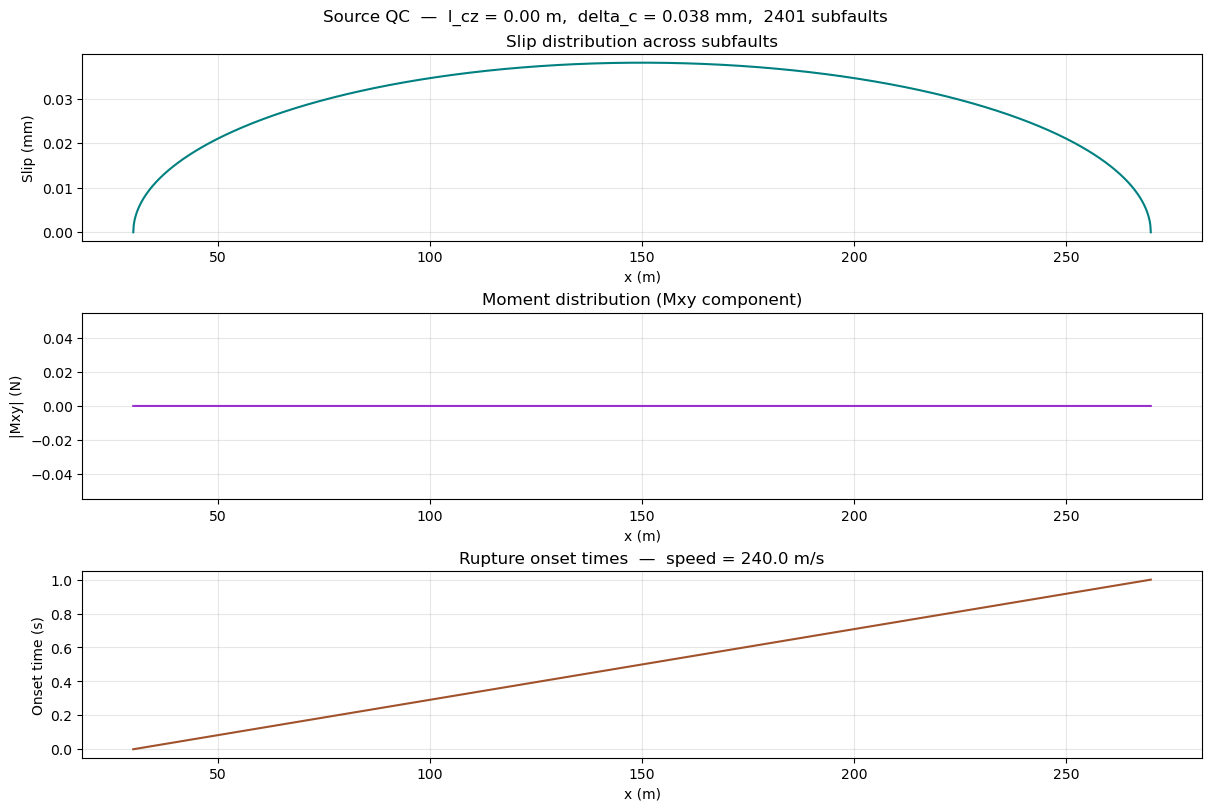

Slip range:        0.0000 – 0.0380 mm
Non-zero |Mxy|:    0 / 2401
Onset time range:  0.0000 – 1.0000 s
Rupture duration:  1.0000 s


In [12]:
# Quick diagnostic — run this before launching the simulation


x_positions = np.array([sf["x"] for sf in subfaults])
slips       = np.array([sf["slip"] for sf in subfaults])
mxy_vals    = np.array([sf["mxy"] for sf in subfaults])
onset_times = np.array([sf["onset_time"] for sf in subfaults])

fig, axes = plt.subplots(3, 1, figsize=(12, 8), constrained_layout=True)

axes[0].plot(x_positions, slips * 1000, color="teal")
axes[0].set_ylabel("Slip (mm)")
axes[0].set_title("Slip distribution across subfaults")
axes[0].grid(alpha=0.3)

axes[1].plot(x_positions, np.abs(mxy_vals), color="darkorchid")
axes[1].set_ylabel("|Mxy| (N)")
axes[1].set_title("Moment distribution (Mxy component)")
axes[1].grid(alpha=0.3)

axes[2].plot(x_positions, onset_times, color="sienna")
axes[2].set_ylabel("Onset time (s)")
axes[2].set_title(f"Rupture onset times  —  speed = {rupture_speed:.1f} m/s")
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel("x (m)")

plt.suptitle(f"Source QC  —  l_cz = {czm['l_cz']:.2f} m,  delta_c = {czm['delta_c']*1000:.3f} mm,  {len(subfaults)} subfaults")
display(fig)
plt.close(fig)

# Print summary numbers
print(f"Slip range:        {slips.min()*1000:.4f} – {slips.max()*1000:.4f} mm")
print(f"Non-zero |Mxy|:    {np.sum(np.abs(mxy_vals) > 1e-15)} / {len(subfaults)}")
print(f"Onset time range:  {onset_times.min():.4f} – {onset_times.max():.4f} s")
print(f"Rupture duration:  {onset_times[-1] + subfaults[-1]['rise_time']:.4f} s")

In [13]:
czm_sim_name = "sim_snow_crack_czm"

# Time calculations
rupture_duration = subfaults[-1]["onset_time"] + subfaults[-1]["rise_time"]
positive_vs = vs[vs > 0]
travel_velocity = float(np.min(positive_vs))
end_time = 2.0  # Your manual override

# Add metadata  only config to project 
p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        name=czm_sim_name,
        unstructured_mesh=mesh_3layer,
        event_configuration=sn.EventConfiguration(
            wavelet=sn.simple_config.stf.Delta(), # Placeholder wavelet
            waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                start_time_in_seconds=-0.3,
                end_time_in_seconds=end_time,
            ),
        ),
    ),
    overwrite=True,
)



# Template fetch only simulation name: NO SOURCES 
input_file = p.simulations.get_simulation_template(czm_sim_name)

# Manually inject sources built above
input_file.add_sources(czm_srcs)


# Print sour ces to verify if correct ones were used 
print(f"Verified: {len(input_file.physics.wave_equation.point_source)} sources loaded with timing intact.")

# Output config
del input_file.output.point_data
input_file.output.volume_data = {
    "filename": "volume_data_czm.h5",
    "format": "hdf5",
    "fields": ["velocity", "displacement", "strain"],
    "sampling_interval_in_time_steps": 50,
}

# launch 
input_file.validate()
czm_output_folder = str(pathlib.Path(PROJECT_DIR) / "job_snow_crack_czm")
czm_job = sn.api.run(
    input_file=input_file,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=czm_output_folder,
    get_all=True,
    overwrite=True,
)

print(f"Run finished. Output: {czm_output_folder}")

Verified: 2401 sources loaded with timing intact.
SalvusJob `job_2605121438716978_808e51263f` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/7867 [00:00<?, ?it/s]

* Downloaded 81.2 MB of results to `simulation_fault_zone_czm_mode1/job_snow_crack_czm`.
* Total run time: 9.88 seconds.
* Pure simulation time: 8.02 seconds.
Run finished. Output: simulation_fault_zone_czm_mode1/job_snow_crack_czm


In [14]:
# czm_sim_name = "sim_snow_crack_czm"

# # End time must cover full rupture duration plus wave travel time.
# # Use the slowest positive shear velocity from the solid layers (air has vs=0).
# rupture_duration = subfaults[-1]["onset_time"] + subfaults[-1]["rise_time"]
# positive_vs = vs[vs > 0]
# if positive_vs.size == 0:
#     raise ValueError("No positive shear-wave velocity found in `vs`; cannot compute finite end_time.")
# travel_velocity = float(np.min(positive_vs))
# end_time = 2.0
# #end_time = rupture_duration + 300.0 / travel_velocity + 0.5  # rupture + wave travel + margin

# if not np.isfinite(end_time):
#     raise ValueError(f"Computed non-finite end_time={end_time}; check velocity model.")

# print(f"Rupture duration: {rupture_duration:.3f} s")
# print(f"Travel velocity for end-time estimate: {travel_velocity:.3f} m/s")
# print(f"Simulation end time: {end_time:.3f} s")

# p.add_to_project(
#     sn.UnstructuredMeshSimulationConfiguration(
#         name=czm_sim_name,
#         unstructured_mesh=mesh_3layer,
#         event_configuration=sn.EventConfiguration(
#             wavelet=sn.simple_config.stf.Delta(),
#             waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
#                 start_time_in_seconds=-0.3,
#                 end_time_in_seconds=end_time,
#             ),
#         ),
#     ),
#     overwrite=True,
# )

# input_file = p.simulations.get_simulation_template(czm_sim_name, czm_event_name)
# input_file.add_sources(czm_srcs)

# assert len(input_file.physics.wave_equation.point_source) == len(czm_srcs), \
#     f"Source count mismatch: expected {len(czm_srcs)}, got " \
#     f"{len(input_file.physics.wave_equation.point_source)}"

# del input_file.output.point_data

# input_file.output.volume_data = {
#     "filename": "volume_data_czm.h5",
#     "format": "hdf5",
#     "fields": ["velocity", "displacement", "strain"],
#     "sampling_interval_in_time_steps": 50,
# }

# input_file.validate()

# czm_output_folder = str(pathlib.Path(PROJECT_DIR) / "job_snow_crack_czm")
# czm_job = sn.api.run(
#     input_file=input_file,
#     site_name=SALVUS_FLOW_SITE_NAME,
#     ranks=RANKS_PER_JOB,
#     output_folder=czm_output_folder,
#     get_all=True,
#     overwrite=True,
# )
# print(f"Run finished. Output: {czm_output_folder}")

In [15]:
# Extract displacement wavefield output from the single combined run.
czm_output_folder = str(pathlib.Path(PROJECT_DIR) / "job_snow_crack_czm")
vol_file = pathlib.Path(czm_output_folder) / "volume_data_czm.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

dis_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "displacement",
    "volume",
)

dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    dis_wo,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

print(f"Loaded displacement from {vol_file}")
print(f"Shape: {dis_2d_layered.dims}")
print(dis_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-05-12 14:39:00,881] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded displacement from simulation_fault_zone_czm_mode1/job_snow_crack_czm/volume_data_czm.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 159, c: 2, x: 401, y: 101)> Size: 52MB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,            nan,            nan, ...,
     

In [16]:
# Take the spatial derivative of the layered displacement field along x.
x_dim = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered.dims or dim in dis_2d_layered.coords), None)

if x_dim is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={dis_2d_layered.dims}, coords={list(dis_2d_layered.coords)}"
    )

dis_2d_layered_dx = dis_2d_layered.differentiate(x_dim)

print(f"Computed spatial derivative d/d{x_dim} for dis_2d_layered")
print(dis_2d_layered_dx)

Computed spatial derivative d/dx for dis_2d_layered
<xarray.DataArray (t: 159, c: 2, x: 401, y: 101)> Size: 52MB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [       

In [17]:
# Extract velocity wavefield output from the CZM run.
vol_file = pathlib.Path(czm_output_folder) / "volume_data_czm.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the CZM launch cell and verify the job completed."
    )

vel_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "velocity",
    "volume",
)

vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

print(f"Loaded velocity from {vol_file}")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-05-12 14:39:11,315] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded velocity from simulation_fault_zone_czm_mode1/job_snow_crack_czm/volume_data_czm.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 159, c: 2, x: 401, y: 101)> Size: 52MB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[            nan,          

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.3 -> 2.0096478962755815
vx shape: (159, 401)
vy shape: (159, 401)


/tmp/ipykernel_2429197/1720796821.py:56: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_2429197/1720796821.py:78: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


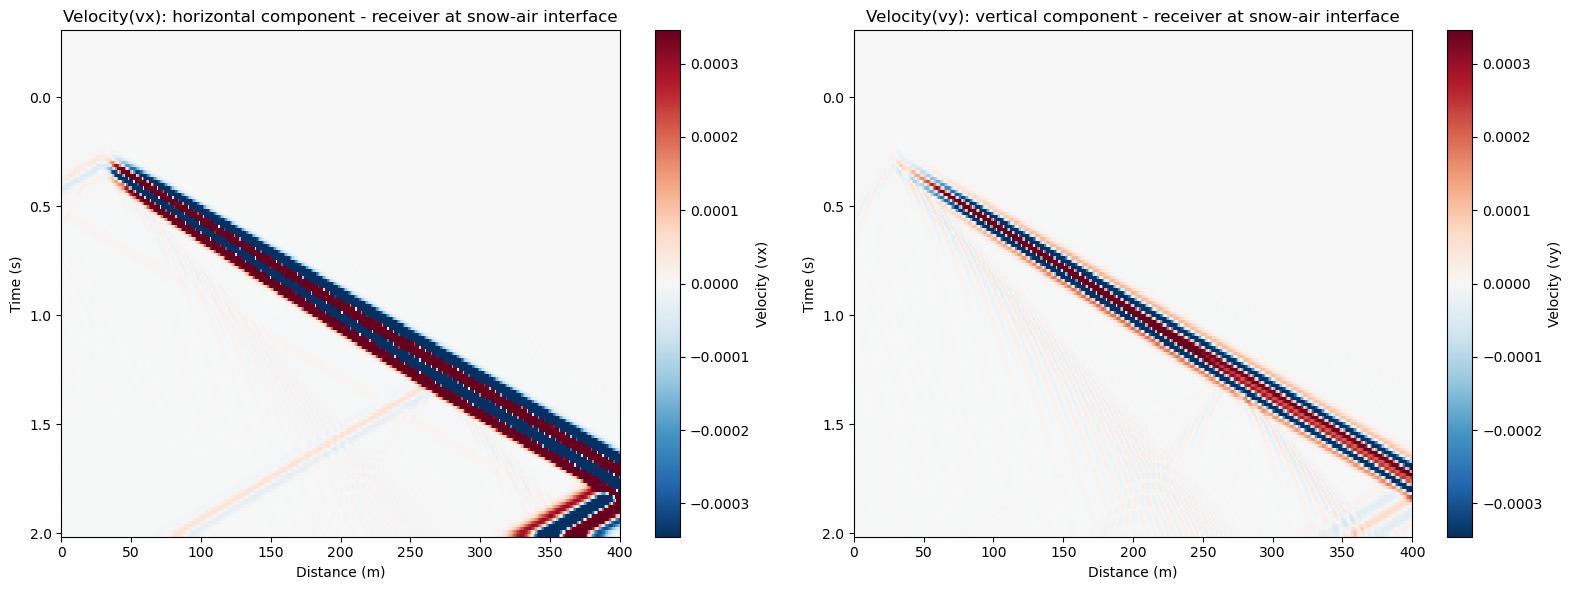

In [18]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 1.5 # This would be at snow-air boundary 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx): horizontal component - receiver at snow-air interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy): vertical component - receiver at snow-air interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)


imshow diagnostics: vx[min,max]=(-9.174e-03, 8.329e-03), vy[min,max]=(-8.380e-04, 1.184e-03), vmax=3.453e-04


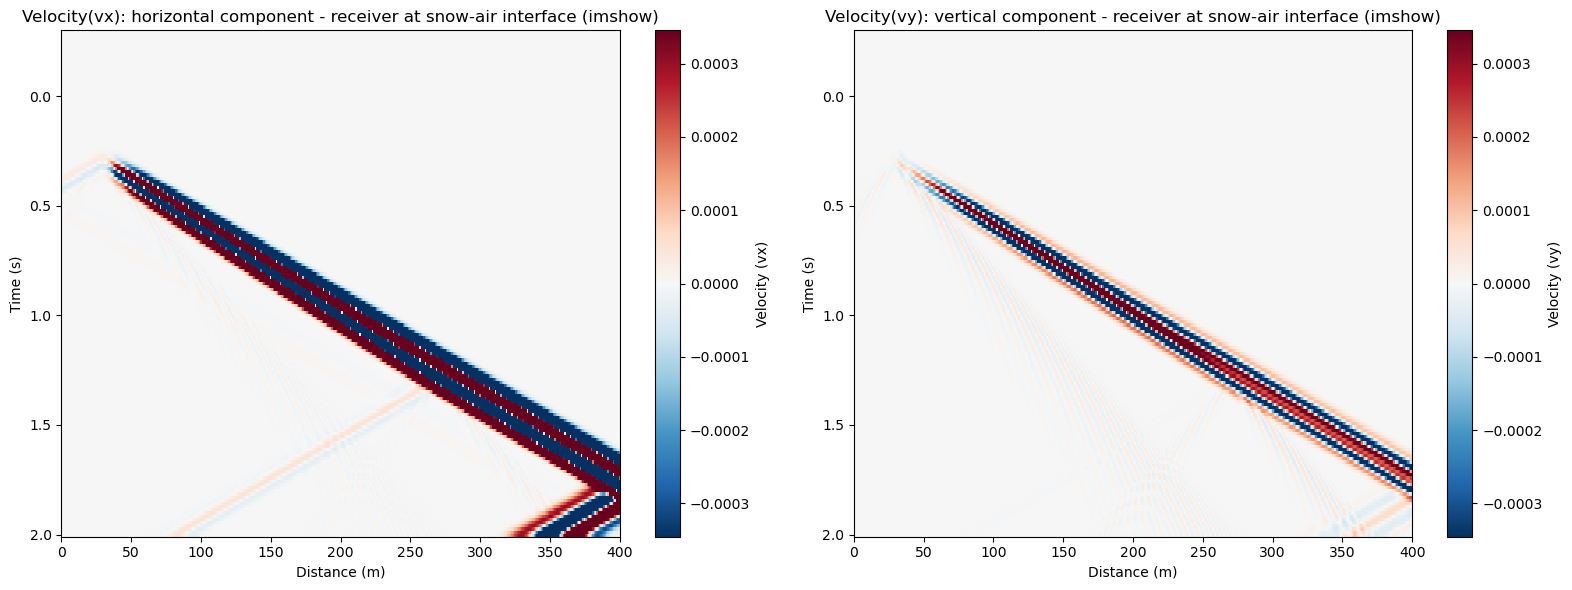

In [19]:
# Plot with imshow and make rendering robust in notebook output.
from IPython.display import display

# Force inline backend in notebook sessions (safe no-op if unavailable).
try:
    plt.switch_backend("module://matplotlib_inline.backend_inline")
except Exception:
    pass

required_vars = ["data_vx", "data_vy", "x_line", "t_vals"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError(
        f"Missing variables for imshow plot: {missing_vars}. "
        "Run the previous velocity gather cell first."
    )

vx = np.asarray(data_vx, dtype=float)
vy = np.asarray(data_vy, dtype=float)
x = np.asarray(x_line, dtype=float)
t = np.asarray(t_vals, dtype=float)

if vx.ndim != 2 or vy.ndim != 2:
    raise ValueError(f"Expected 2D arrays for data_vx/data_vy, got {vx.ndim}D and {vy.ndim}D.")

# NaN-safe symmetric color scale shared across both panels.
all_abs = np.abs(np.concatenate([vx.ravel(), vy.ravel()]))
vmax = float(np.nanpercentile(all_abs, 95))
if not np.isfinite(vmax) or vmax <= 0.0:
    vmax = 1e-12

extent = [float(np.nanmin(x)), float(np.nanmax(x)), float(np.nanmax(t)), float(np.nanmin(t))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im_vx = axes[0].imshow(
    vx,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    extent=extent,
    origin="upper",
    interpolation="none",
)
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_title("Velocity(vx): horizontal component - receiver at snow-air interface (imshow)")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

im_vy = axes[1].imshow(
    vy,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    extent=extent,
    origin="upper",
    interpolation="none",
)
axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_title("Velocity(vy): vertical component - receiver at snow-air interface (imshow)")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()
print(f"imshow diagnostics: vx[min,max]=({np.nanmin(vx):.3e}, {np.nanmax(vx):.3e}), "
      f"vy[min,max]=({np.nanmin(vy):.3e}, {np.nanmax(vy):.3e}), vmax={vmax:.3e}")
display(fig)
plt.close(fig)

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.3 -> 2.0096478962755815
vx shape: (159, 401)
vy shape: (159, 401)


/tmp/ipykernel_2429197/2807949046.py:58: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_2429197/2807949046.py:80: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


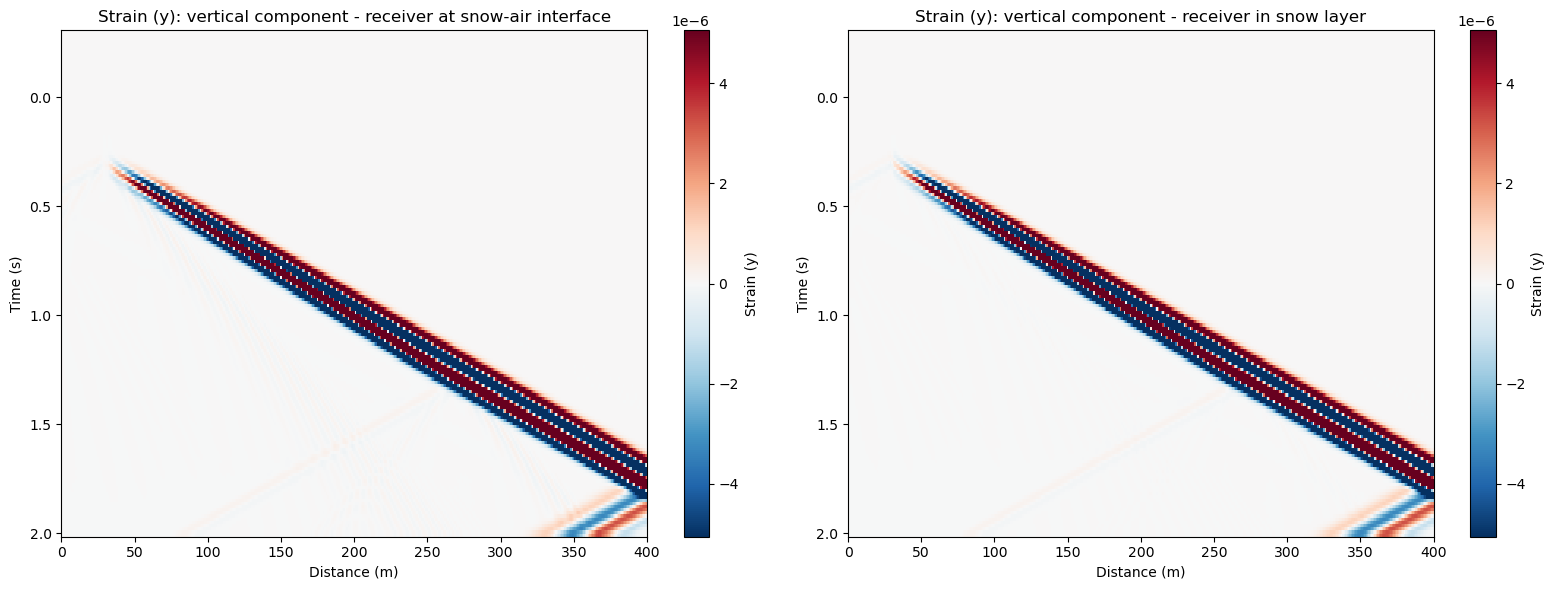

In [20]:
# Plottining strain for two different reciever lines 
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface_1 = 1.5
y_surface_2 = 2.5

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_strain_y_1 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_1}, method="nearest")
sg_strain_y_2 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_2}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_strain_y_1.dims:
    sg_strain_y_1_plot = sg_strain_y_1.mean(dim=e_name)
    sg_strain_y_2_plot = sg_strain_y_2.mean(dim=e_name)
else:
    sg_strain_y_1_plot = sg_strain_y_1
    sg_strain_y_2_plot = sg_strain_y_2

# Ensure plotting order is (time, x)
sg_strain_y_1_plot = sg_strain_y_1_plot.transpose(t_name, x_name)
sg_strain_y_2_plot = sg_strain_y_2_plot.transpose(t_name, x_name)

t_vals = sg_strain_y_1_plot[t_name].values
x_line = sg_strain_y_1_plot[x_name].values
data_vx = sg_strain_y_1_plot.values
data_vy = sg_strain_y_2_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Strain (y): vertical component - receiver at snow-air interface")
plt.colorbar(im_vx, ax=axes[0], label="Strain (y)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Strain (y): vertical component - receiver in snow layer")
plt.colorbar(im_vy, ax=axes[1], label="Strain (y)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)


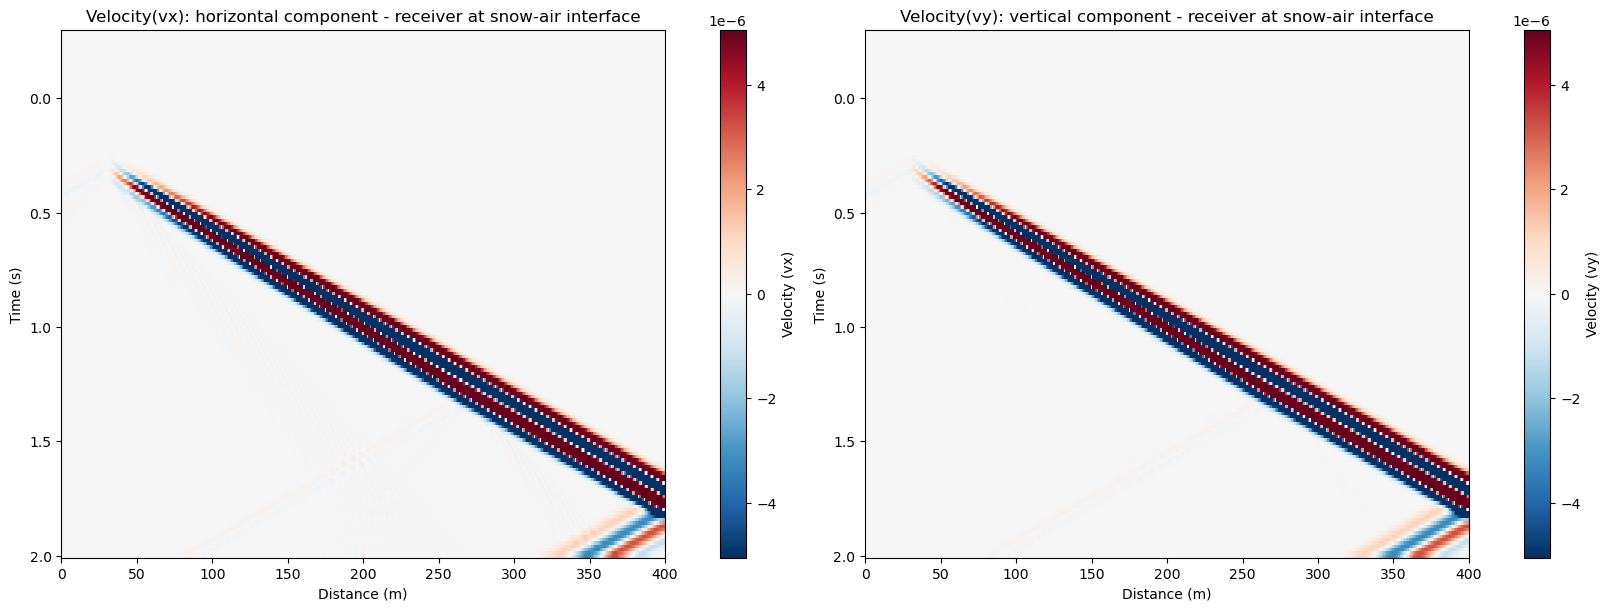

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# EXACT same scaling for both panels as the pcolormesh version
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)
norm = matplotlib.colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

# Same geometry/orientation as pcolormesh + invert_yaxis()
extent = [x_line.min(), x_line.max(), t_vals.max(), t_vals.min()]

im_vx = axes[0].imshow(
    data_vx,
    extent=extent,
    aspect="auto",
    origin="upper",
    cmap="RdBu_r",
    norm=norm,
    interpolation="none", # closest to pcolormesh(shading="none")
    resample=False,
)
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx): horizontal component - receiver at snow-air interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

im_vy = axes[1].imshow(
    data_vy,
    extent=extent,
    aspect="auto",
    origin="upper",
    cmap="RdBu_r",
    norm=norm,
    interpolation="none", # closest to pcolormesh(shading="none")
    resample=False,
)
axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy): vertical component - receiver at snow-air interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

display(fig)
plt.close(fig)



Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-05-12 14:39:23,173] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Using latest wavefield file: simulation_fault_zone_czm_mode1/job_snow_crack_czm/volume_data_czm.h5
representative_event: combined over all events
t range:        -0.300 -> 2.010 s
frames to anim: 18 (from 18 total selected frames)
vmax=4.259e-04


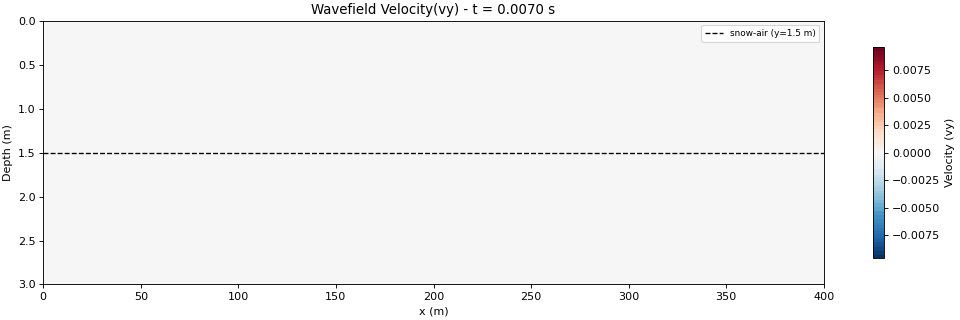

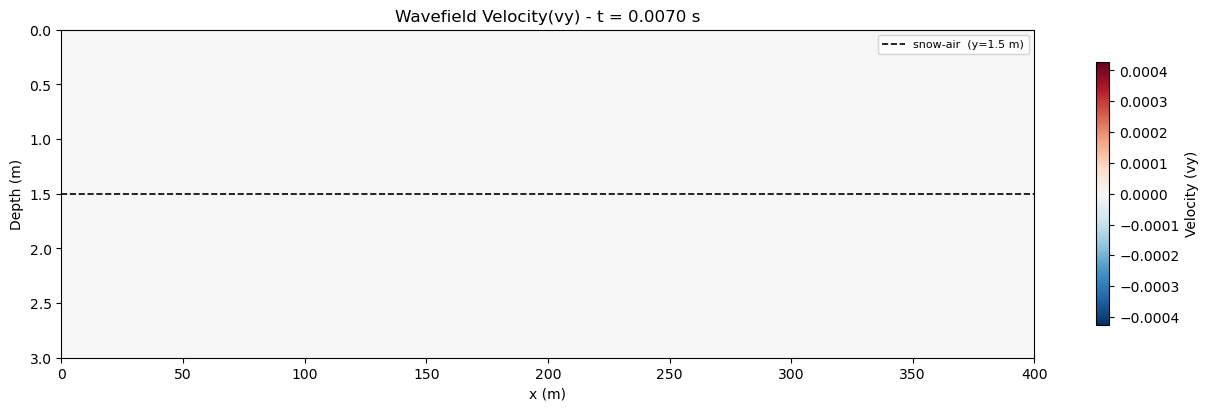

In [22]:
# Self-contained wavefield animation cell (safe to run after kernel restart).
import pathlib
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import Image as IPImage, display
from salvus.toolbox.helpers import wavefield_output

# Always reload the latest simulation output from disk so the animation cannot
# accidentally reuse a stale in-memory wavefield from an earlier run.
project_dir = pathlib.Path(globals().get("PROJECT_DIR", "simulation_fault_zone_czm_adjusted_time_domain_supershear"))
output_candidates = sorted(project_dir.glob("**/volume_data_czm.h5"), key=lambda path: path.stat().st_mtime, reverse=True)
if not output_candidates:
    raise RuntimeError(f"Missing output file under {project_dir}: volume_data_czm.h5")
vol_file = output_candidates[0]
czm_output_folder = str(vol_file.parent)

vel_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "velocity", "volume")
vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

# Resolve coordinate names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)
x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)
if None in [x_name, y_name, t_name, c_name]:
    raise ValueError(f"Could not resolve dimensions from dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Build a combined vy field across all events.
vy_event = vel_2d_layered.isel({c_name: 1})
if e_name is not None and e_name in vy_event.dims:
    vy_event = vy_event.mean(dim=e_name)
vy_event = vy_event.transpose(t_name, y_name, x_name)

x_vals = vy_event[x_name].values
y_vals = vy_event[y_name].values
t_vals = vy_event[t_name].values
frames_3d = np.asarray(vy_event.values, dtype=np.float64)
frames_3d = np.nan_to_num(frames_3d, nan=0.0, posinf=0.0, neginf=0.0)

# Time subsampling starting from t=0 and cap total frames for reliable save.
t_start_idx = np.searchsorted(t_vals, 0.0)
N = 8
raw_idx = np.arange(t_start_idx, frames_3d.shape[0], N)
if raw_idx.size == 0:
    raise ValueError("No frames selected for animation.")
max_frames = 350
t_idx = raw_idx[:max_frames]

# Robust symmetric color scaling from selected frames only.
sample_abs = np.abs(frames_3d[t_idx]).ravel()
sample_abs = sample_abs[np.isfinite(sample_abs)]
sample_abs = sample_abs[sample_abs > 1e-14]
if sample_abs.size == 0:
    vmax = 1e-8
else:
    vmax = max(float(np.percentile(sample_abs, 99.0)), 1e-8)
norm = matplotlib.colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

print(f"Using latest wavefield file: {vol_file}")
print("representative_event: combined over all events")
print(f"t range:        {t_vals[0]:.3f} -> {t_vals[-1]:.3f} s")
print(f"frames to anim: {len(t_idx)} (from {len(raw_idx)} total selected frames)")
print(f"vmax={vmax:.3e}")

fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
im = ax.imshow(
    frames_3d[t_idx[0]],
    extent=[x_vals.min(), x_vals.max(), y_vals.max(), y_vals.min()],
    aspect="auto",
    cmap="RdBu_r",
    norm=norm,
    origin="upper",
    interpolation="nearest",
)

receiver_y = 1.5
ax.axhline(receiver_y, color="black", lw=1.2, linestyle="--", label=f"snow-air  (y={receiver_y:.1f} m)")
#ax.axhline(1.05, color="gray", lw=1.2, linestyle="--", label="weak layer-air (y=1.05 m)")
ax.set_xlabel("x (m)")
ax.set_ylabel("Depth (m)")
ax.set_xlim(x_vals.min(), x_vals.max())
ax.set_ylim(y_vals.max(), y_vals.min())
ax.legend(loc="upper right", fontsize=8)
plt.colorbar(im, ax=ax, label="Velocity (vy)", shrink=0.8)
title = ax.set_title(f"Wavefield Velocity(vy) - t = {t_vals[t_idx[0]]:.4f} s")


def update(frame_idx):
    ti = t_idx[frame_idx]
    im.set_data(frames_3d[ti])
    title.set_text(f"Wavefield Velocity(vy) - t = {t_vals[ti]:.4f} s")
    return im, title


ani = animation.FuncAnimation(fig, update, frames=len(t_idx), interval=90, blit=False)

# Save synchronously for complete files.
if animation.writers.is_available("ffmpeg"):
    writer = animation.FFMpegWriter(
        fps=15,
        codec="libx264",
        extra_args=["-pix_fmt", "yuv420p", "-crf", "28"],
    )
    output_name = "wavefield_2d_moving_czm.mp4"
else:
    writer = animation.PillowWriter(fps=10)
    output_name = "wavefield_2d_moving_czm.gif"

    "print(f\"Saving {output_name}...\")",
    "ani.save(output_name, writer=writer, dpi=80)",
    "plt.close(fig)",
    "print(f\"Done! Saved as {output_name}\")",

if output_name.lower().endswith(".gif"):
    display(IPImage(filename=output_name))

Estimated rupture speed from picks : 272.7 m/s
Model input rupture speed          : 240.0 m/s


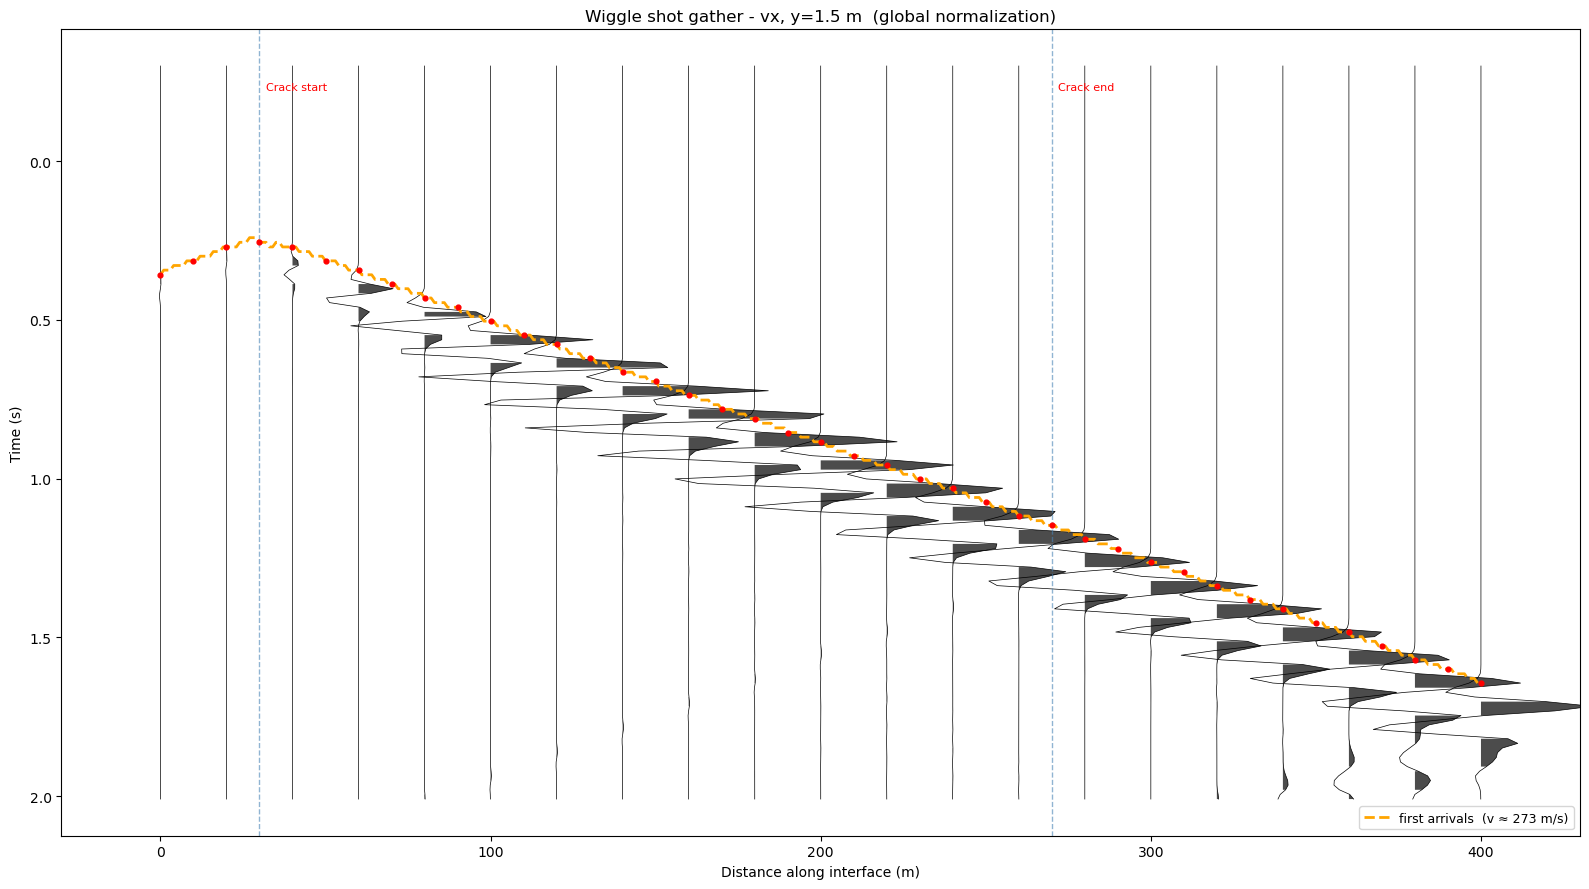

In [23]:
# Wiggle plot with global normalization to reveal backscattering


# shotgather setup
sg = sg_vx  # component to plot (swap to sg_vy for vertical)
rec_dim = [d for d in sg.dims if d != "t"][0]
sg = sg.assign_coords({rec_dim: x_line}).rename({rec_dim: "x"})
sg_tx = sg.transpose("t", "x") # (time, distance)

t = sg_tx["t"].values
x = sg_tx["x"].values
A = sg_tx.values # shape: (nt, nx)

# Plot settings
trace_step   = 20 # plot every Nth receiver
wiggle_scale = 1.5 * np.median(np.diff(x)) * trace_step # slightly wider for global norm

# Global normaization of traces 
tr_global_max = np.percentile(np.abs(A), 99) # 99th percentile avoids one noisy spike
if tr_global_max < 1e-20:
    raise RuntimeError("All traces appear to be zero — check sg_vx.")

# First arrival picks 
pick_threshold = 0.05 # fraction of each trace's own max (only used for picking)
first_arrival_times = np.full(len(x), np.nan)

for i in range(len(x)):
    tr = A[:, i].copy()
    tr_max = np.max(np.abs(tr))
    if tr_max < 1e-20:
        continue
    tr /= tr_max # per-trace norm only for picking
    start_idx = np.searchsorted(t, 0.0)
    crossing  = np.where(np.abs(tr[start_idx:]) >= pick_threshold)[0]
    if crossing.size > 0:
        first_arrival_times[i] = t[start_idx + crossing[0]]

# Rupture speed estimation from picks 
valid = np.isfinite(first_arrival_times)
if np.sum(valid) >= 2:
    coeffs            = np.polyfit(x[valid], first_arrival_times[valid], 1)
    rupture_speed_obs = 1.0 / coeffs[0] if coeffs[0] != 0 else np.inf
    print(f"Estimated rupture speed from picks : {rupture_speed_obs:.1f} m/s")
    print(f"Model input rupture speed          : {rupture_speed:.1f} m/s")
else:
    rupture_speed_obs = None
    print("Not enough valid picks to estimate rupture speed.")



# Plotting
fig, ax = plt.subplots(figsize=(16, 9))

for i in range(0, len(x), trace_step):
    tr = A[:, i].copy()
    x0 = x[i]

    if np.max(np.abs(tr)) < 1e-20:
        continue

    tr /= tr_global_max   # global norm (reveals backscatter)

    xwig = x0 + wiggle_scale * tr
    ax.plot(xwig, t, color="black", lw=0.5)
    ax.fill_betweenx(t, x0, xwig,
                     where=(tr > 0),
                     color="black", alpha=0.7, linewidth=0)

# first-arrival curve
if valid.any():
    ax.plot(x[valid], first_arrival_times[valid],
            color="orange", linestyle="--", lw=2.0,
            label=f"first arrivals  (v ≈ {rupture_speed_obs:.0f} m/s)" if rupture_speed_obs else "first arrivals")
    ax.scatter(x[valid][::max(1, trace_step // 2)],
               first_arrival_times[valid][::max(1, trace_step // 2)],
               color="red", s=12, zorder=5)

# expected backscatter moveout from far crack tip (slope = 1/vs, origin at tip)
x_plot = np.linspace(0, 400, 400)
for recv_x in x_plot:
    pass  # compute per-receiver below as a curve


# crack extent markers
for cx, label in [(30.0, "Crack start"), (270.0, "Crack end")]:
    ax.axvline(cx, color="steelblue", lw=1.0, linestyle="--", alpha=0.6)
    ax.text(cx + 2, t[0] + 0.05, label, color="red", fontsize=8, va="top")

ax.invert_yaxis()
ax.set_xlim(x[0] - wiggle_scale, x[-1] + wiggle_scale)
ax.set_xlabel("Distance along interface (m)")
ax.set_ylabel("Time (s)")
ax.set_title("Wiggle shot gather - vx, y=1.5 m  (global normalization)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
display(fig)
plt.close(fig)

Sampling frequency: 68.4 Hz
Nyquist frequency:  34.2 Hz


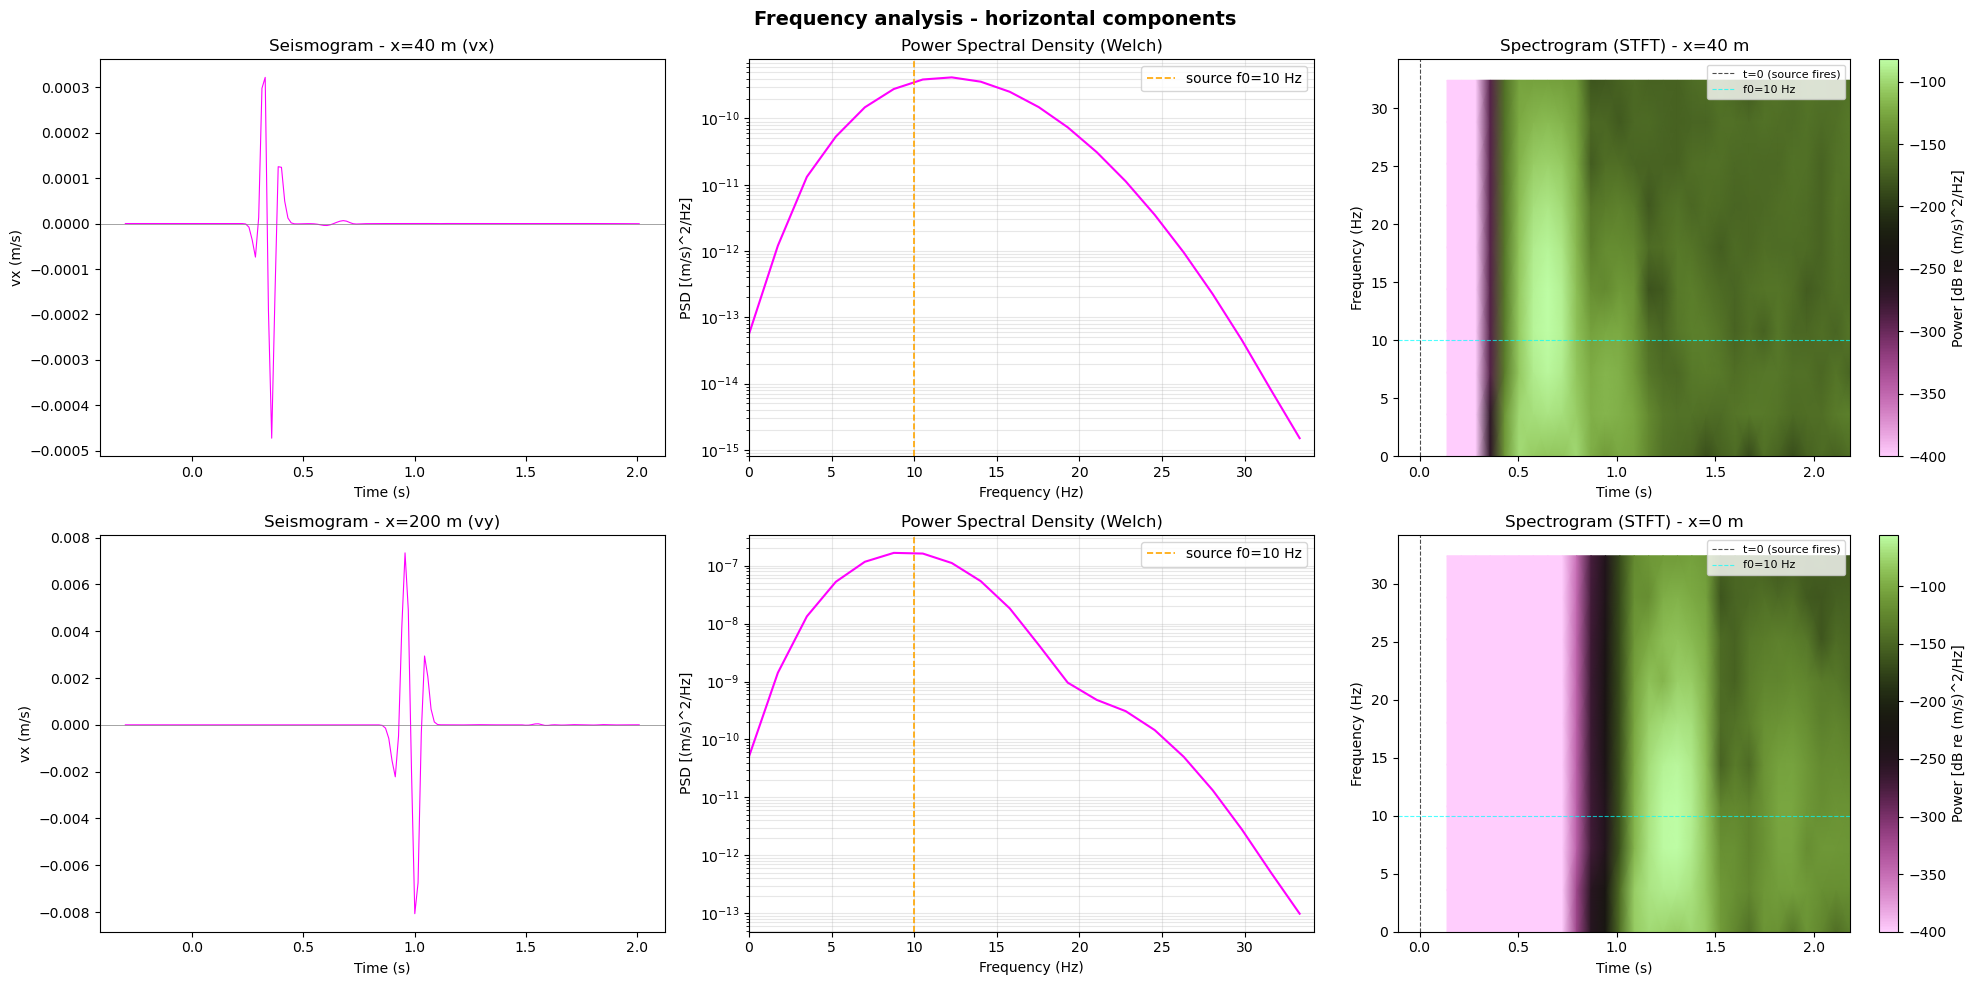

In [24]:

# Extract traces from two receiver locations
# Receiver 1: x-index 30 (sg_vx - horizontal component)
trace_1 = sg_vx.isel({x_name: 40})
t_vals_1 = trace_1.t.values
y_vals_1 = trace_1.values

# Receiver 2: x-index 0 (sg_vy - vertical component)
trace_2 = sg_vx.isel({x_name: 200})
t_vals_2 = trace_2.t.values
y_vals_2 = trace_2.values

# dt and sampling frequency
dt = float(np.diff(t_vals_1).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

# Create 2x3 subplot figure
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# ===== RECEIVER 1 (Horizontal component, x=150m) =====

# Row 0, Col 0: Raw seismogram
axes[0, 0].plot(t_vals_1, y_vals_1, lw=0.8, color="magenta")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("vx (m/s)")
axes[0, 0].set_title("Seismogram - x=40 m (vx)")
axes[0, 0].axhline(0, color="gray", lw=0.5)

# Row 0, Col 1: Power Spectral Density
nperseg = min(1024, len(y_vals_1) // 4)
freqs_psd_1, psd_1 = signal.welch(
    y_vals_1,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)
axes[0, 1].semilogy(freqs_psd_1, psd_1, color="magenta")
axes[0, 1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[0, 1].set_title("Power Spectral Density (Welch)")
axes[0, 1].set_xlim(0, fs / 2)
axes[0, 1].legend()
axes[0, 1].grid(True, which="both", alpha=0.3)

# Row 0, Col 2: Spectrogram
nperseg_stft = min(512, len(y_vals_1) // 8)
freqs_stft_1, t_stft_1, Sxx_1 = signal.spectrogram(
    y_vals_1,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,
    window="hann",
    scaling="density",
)
Sxx_log_1 = 10 * np.log10(Sxx_1 + 1e-40)

im0 = axes[0, 2].pcolormesh(
    t_stft_1, freqs_stft_1, Sxx_log_1,
    shading="gouraud",
    cmap="vanimo",
)
axes[0, 2].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[0, 2].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[0, 2].set_xlabel("Time (s)")
axes[0, 2].set_ylabel("Frequency (Hz)")
axes[0, 2].set_title("Spectrogram (STFT) - x=40 m")
axes[0, 2].set_ylim(0, min(100, fs / 2))
axes[0, 2].legend(loc="upper right", fontsize=8)
cbar0 = fig.colorbar(im0, ax=axes[0, 2], label="Power [dB re (m/s)^2/Hz]")

# ===== RECEIVER 2 (Vertical component, x=0m) =====

# Row 1, Col 0: Raw seismogram
axes[1, 0].plot(t_vals_2, y_vals_2, lw=0.8, color="magenta")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("vx (m/s)")
axes[1, 0].set_title("Seismogram - x=200 m (vy)")
axes[1, 0].axhline(0, color="gray", lw=0.5)

# Row 1, Col 1: Power Spectral Density
nperseg = min(1024, len(y_vals_2) // 4)
freqs_psd_2, psd_2 = signal.welch(
    y_vals_2,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)
axes[1, 1].semilogy(freqs_psd_2, psd_2, color="magenta")
axes[1, 1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1, 1].set_title("Power Spectral Density (Welch)")
axes[1, 1].set_xlim(0, fs / 2)
axes[1, 1].legend()
axes[1, 1].grid(True, which="both", alpha=0.3)

# Row 1, Col 2: Spectrogram
nperseg_stft = min(512, len(y_vals_2) // 8)
freqs_stft_2, t_stft_2, Sxx_2 = signal.spectrogram(
    y_vals_2,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,
    window="hann",
    scaling="density",
)
Sxx_log_2 = 10 * np.log10(Sxx_2 + 1e-40)

im1 = axes[1, 2].pcolormesh(
    t_stft_2, freqs_stft_2, Sxx_log_2,
    shading="gouraud",
    cmap="vanimo",
)
axes[1, 2].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[1, 2].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[1, 2].set_xlabel("Time (s)")
axes[1, 2].set_ylabel("Frequency (Hz)")
axes[1, 2].set_title("Spectrogram (STFT) - x=0 m")
axes[1, 2].set_ylim(0, min(100, fs / 2))
axes[1, 2].legend(loc="upper right", fontsize=8)
cbar1 = fig.colorbar(im1, ax=axes[1, 2], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Frequency analysis - horizontal components", fontsize=14, fontweight="bold")
plt.tight_layout()
display(fig)
plt.close(fig)


Sampling frequency: 68.4 Hz
Nyquist frequency:  34.2 Hz


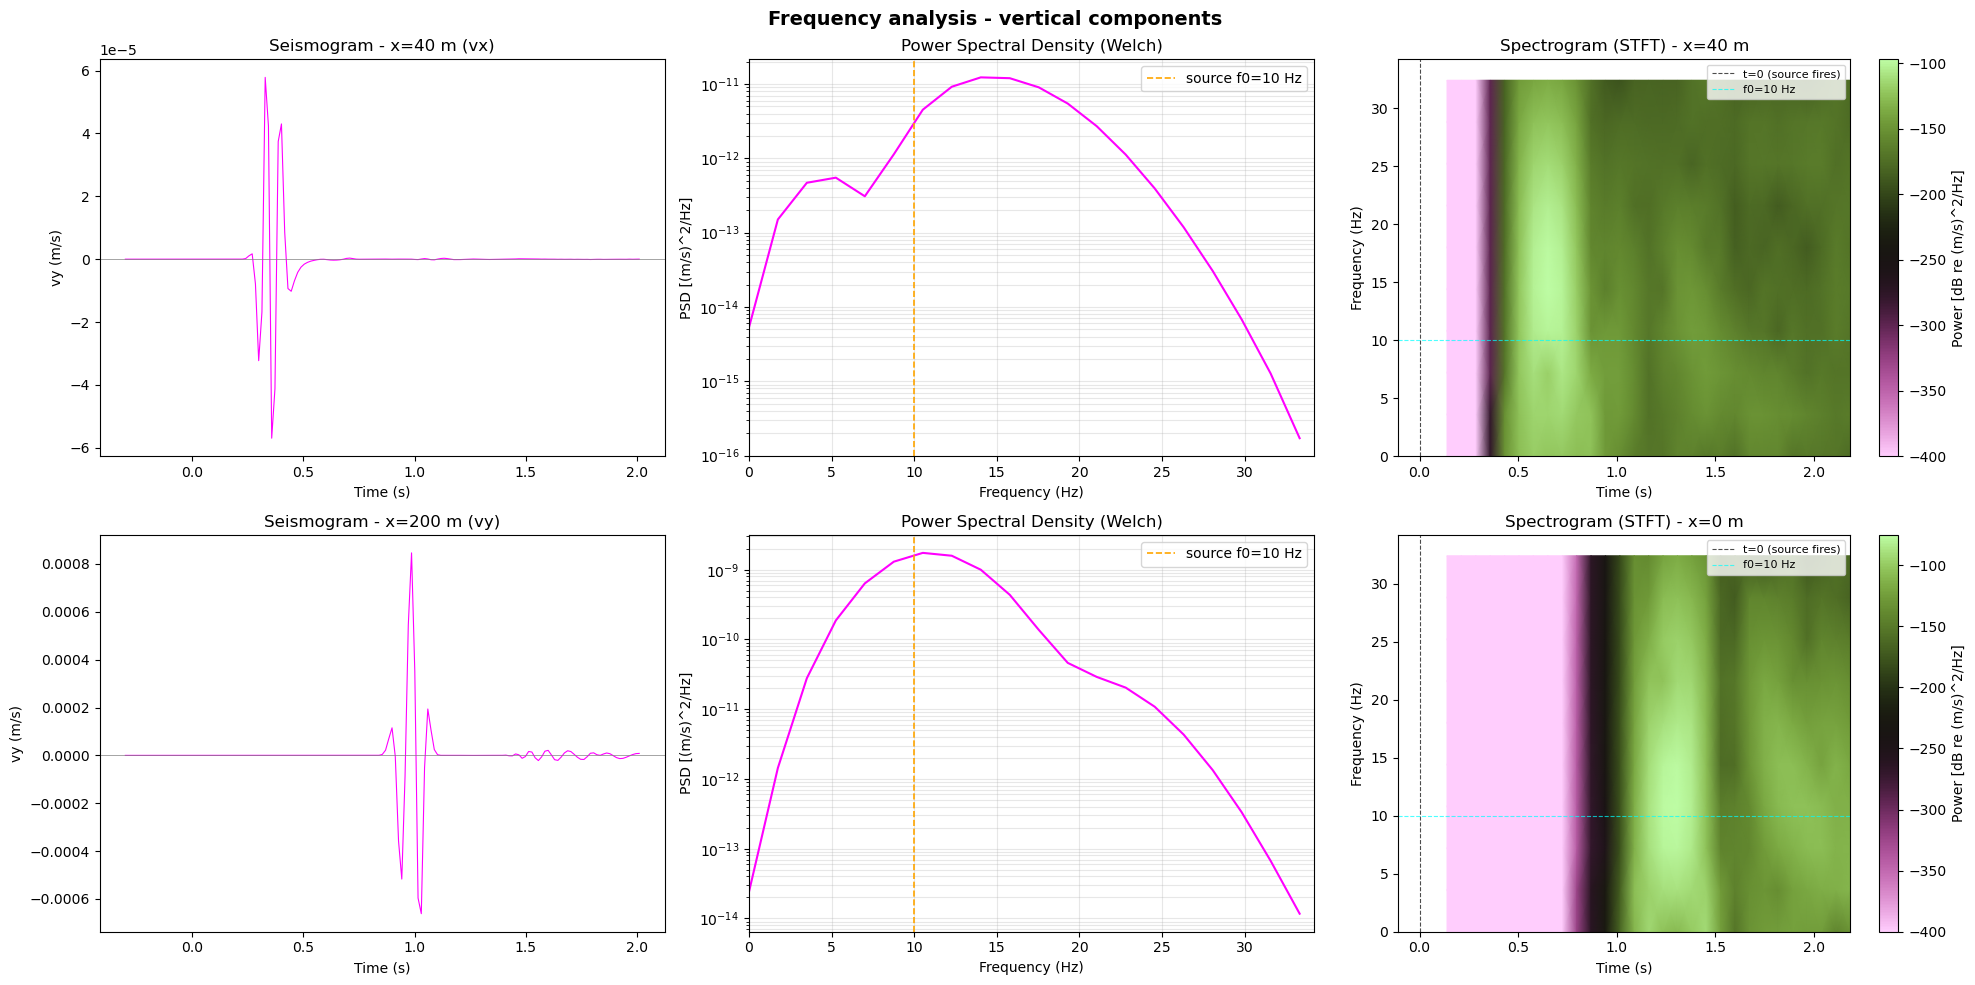

In [25]:

# Extract traces from two receiver locations
# Receiver 1: x-index 30 (sg_vy - vertical component)
trace_1 = sg_vy.isel({x_name: 40})
t_vals_1 = trace_1.t.values
y_vals_1 = trace_1.values

# Receiver 2: x-index 0 (sg_vy - vertical component)
trace_2 = sg_vy.isel({x_name: 200})
t_vals_2 = trace_2.t.values
y_vals_2 = trace_2.values

# dt and sampling frequency
dt = float(np.diff(t_vals_1).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

# Create 2x3 subplot figure
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# ===== RECEIVER 1 (Horizontal component, x=150m) =====

# Row 0, Col 0: Raw seismogram
axes[0, 0].plot(t_vals_1, y_vals_1, lw=0.8, color="magenta")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("vy (m/s)")
axes[0, 0].set_title("Seismogram - x=40 m (vx)")
axes[0, 0].axhline(0, color="gray", lw=0.5)

# Row 0, Col 1: Power Spectral Density
nperseg = min(1024, len(y_vals_1) // 4)
freqs_psd_1, psd_1 = signal.welch(
    y_vals_1,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)
axes[0, 1].semilogy(freqs_psd_1, psd_1, color="magenta")
axes[0, 1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[0, 1].set_title("Power Spectral Density (Welch)")
axes[0, 1].set_xlim(0, fs / 2)
axes[0, 1].legend()
axes[0, 1].grid(True, which="both", alpha=0.3)

# Row 0, Col 2: Spectrogram
nperseg_stft = min(512, len(y_vals_1) // 8)
freqs_stft_1, t_stft_1, Sxx_1 = signal.spectrogram(
    y_vals_1,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,
    window="hann",
    scaling="density",
)
Sxx_log_1 = 10 * np.log10(Sxx_1 + 1e-40)

im0 = axes[0, 2].pcolormesh(
    t_stft_1, freqs_stft_1, Sxx_log_1,
    shading="gouraud",
    cmap="vanimo",
)
axes[0, 2].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[0, 2].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[0, 2].set_xlabel("Time (s)")
axes[0, 2].set_ylabel("Frequency (Hz)")
axes[0, 2].set_title("Spectrogram (STFT) - x=40 m")
axes[0, 2].set_ylim(0, min(100, fs / 2))
axes[0, 2].legend(loc="upper right", fontsize=8)
cbar0 = fig.colorbar(im0, ax=axes[0, 2], label="Power [dB re (m/s)^2/Hz]")

# ===== RECEIVER 2 (Vertical component, x=0m) =====

# Row 1, Col 0: Raw seismogram
axes[1, 0].plot(t_vals_2, y_vals_2, lw=0.8, color="magenta")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("vy (m/s)")
axes[1, 0].set_title("Seismogram - x=200 m (vy)")
axes[1, 0].axhline(0, color="gray", lw=0.5)

# Row 1, Col 1: Power Spectral Density
nperseg = min(1024, len(y_vals_2) // 4)
freqs_psd_2, psd_2 = signal.welch(
    y_vals_2,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)
axes[1, 1].semilogy(freqs_psd_2, psd_2, color="magenta")
axes[1, 1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1, 1].set_title("Power Spectral Density (Welch)")
axes[1, 1].set_xlim(0, fs / 2)
axes[1, 1].legend()
axes[1, 1].grid(True, which="both", alpha=0.3)

# Row 1, Col 2: Spectrogram
nperseg_stft = min(512, len(y_vals_2) // 8)
freqs_stft_2, t_stft_2, Sxx_2 = signal.spectrogram(
    y_vals_2,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,
    window="hann",
    scaling="density",
)
Sxx_log_2 = 10 * np.log10(Sxx_2 + 1e-40)

im1 = axes[1, 2].pcolormesh(
    t_stft_2, freqs_stft_2, Sxx_log_2,
    shading="gouraud",
    cmap="vanimo",
)
axes[1, 2].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[1, 2].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[1, 2].set_xlabel("Time (s)")
axes[1, 2].set_ylabel("Frequency (Hz)")
axes[1, 2].set_title("Spectrogram (STFT) - x=0 m")
axes[1, 2].set_ylim(0, min(100, fs / 2))
axes[1, 2].legend(loc="upper right", fontsize=8)
cbar1 = fig.colorbar(im1, ax=axes[1, 2], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Frequency analysis - vertical components", fontsize=14, fontweight="bold")
plt.tight_layout()
display(fig)
plt.close(fig)


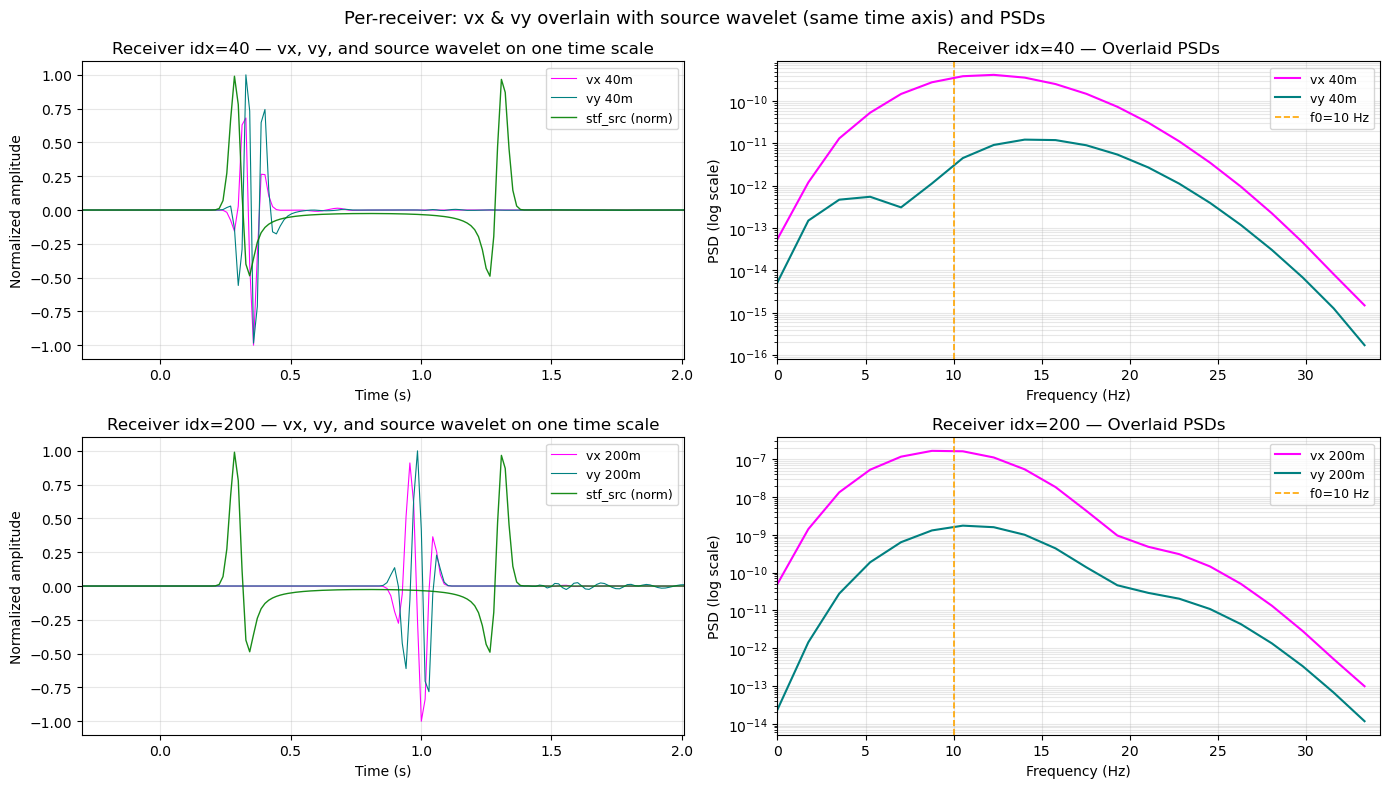

In [26]:
# Per-receiver overlay: vx and vy traces + PSDs, with source wavelet overlaid on traces
# For each receiver (row) we plot: (left) overlaid traces (vx & vy, normalized) + source wavelet
#                                     (right) overlaid PSDs (Welch) — source PSD overlay removed

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import display

# Receiver indices (adjust as needed)
idx_recv = [40, 200]

# --- Build aggregate source STF (scalar norm) to represent the source wavelet ---
pre_delay = 0.3
f0 = 10.0
# match time window used elsewhere
t_start = -pre_delay
t_end = subfaults[-1]["onset_time"] + subfaults[-1]["rise_time"] + 0.5
dt_src = 1e-4
t_src = np.arange(t_start, t_end, dt_src)

def ricker(t, f0, t_shift):
    tau = t - t_shift
    u = (np.pi * f0 * tau) ** 2
    return (1.0 - 2.0 * u) * np.exp(-u)

stf_mxx = np.zeros_like(t_src)
stf_myy = np.zeros_like(t_src)
stf_mxy = np.zeros_like(t_src)
for sf in subfaults:
    t_shift = pre_delay + sf["onset_time"] + sf["rise_time"] / 2.0
    w = ricker(t_src, f0, t_shift)
    stf_mxx += w * sf.get("mxx", 0.0)
    stf_myy += w * sf.get("myy", 0.0)
    stf_mxy += w * sf.get("mxy", 0.0)

# source wavelet, normalized to compare on the same plot as the traces
stf_src = stf_mxx + stf_myy
stf_src_n = stf_src / (np.max(np.abs(stf_src)) + 1e-20)

# compute amplitude spectrum of the source wavelet (kept for diagnostics but not overlaid)
from numpy.fft import rfft, rfftfreq
freqs_src = rfftfreq(len(t_src), dt_src)
spec_src = np.abs(rfft(stf_src))

# Prepare figure
fig, axes = plt.subplots(len(idx_recv), 2, figsize=(14, 4 * len(idx_recv)))
if len(idx_recv) == 1:
    axes = axes[np.newaxis, :]

for i, idx in enumerate(idx_recv):
    # extract traces for this receiver
    tr_vx = sg_vx.isel({x_name: idx})
    tr_vy = sg_vy.isel({x_name: idx})

    t_vx = tr_vx.t.values
    y_vx = tr_vx.values
    t_vy = tr_vy.t.values
    y_vy = tr_vy.values

    # sampling (assume same dt)
    dt = float(np.diff(t_vx).mean())
    fs = 1.0 / dt

    # normalize each trace by its max abs for clear overplot
    y_vx_n = y_vx / (np.max(np.abs(y_vx)) + 1e-20)
    y_vy_n = y_vy / (np.max(np.abs(y_vy)) + 1e-20)

    # Interpolate source wavelet onto the receiver time axis so all three share the same x-axis.
    # Using the vx receiver time vector as the common time scale.
    t_recv = t_vx
    stf_src_on_recv = np.interp(t_recv, t_src, stf_src_n)

    # Left: overlaid normalized traces + source wavelet (all on same time axis)
    ax_tr = axes[i, 0]
    ax_tr.plot(t_recv, y_vx_n, lw=0.8, label=f'vx {idx}m', color='magenta')
    ax_tr.plot(t_recv, y_vy_n, lw=0.8, label=f'vy {idx}m', color='teal')
    ax_tr.plot(t_recv, stf_src_on_recv, lw=1.0, color='green', alpha=0.9, label='stf_src (norm)')
    ax_tr.set_xlabel('Time (s)')
    ax_tr.set_ylabel('Normalized amplitude')
    ax_tr.set_title(f'Receiver idx={idx} — vx, vy, and source wavelet on one time scale')
    ax_tr.set_xlim(t_recv[0], t_recv[-1])
    ax_tr.legend(loc='upper right', fontsize=9)
    ax_tr.grid(alpha=0.3)

    # Right: overlaid PSDs (source PSD overlay removed)
    ax_psd = axes[i, 1]
    nperseg = min(1024, len(y_vx) // 4)
    freqs_vx, psd_vx = signal.welch(y_vx, fs=fs, nperseg=nperseg, noverlap=nperseg//2, window='hann', scaling='density')
    freqs_vy, psd_vy = signal.welch(y_vy, fs=fs, nperseg=nperseg, noverlap=nperseg//2, window='hann', scaling='density')

    ax_psd.semilogy(freqs_vx, psd_vx, label=f'vx {idx}m', color='magenta')
    ax_psd.semilogy(freqs_vy, psd_vy, label=f'vy {idx}m', color='teal')
    ax_psd.axvline(10, color='orange', lw=1.2, linestyle='--', label='f0=10 Hz')
    ax_psd.set_xlabel('Frequency (Hz)')
    ax_psd.set_ylabel('PSD (log scale)')
    ax_psd.set_title(f'Receiver idx={idx} — Overlaid PSDs')
    ax_psd.set_xlim(0, fs/2)
    ax_psd.legend(fontsize=9)
    ax_psd.grid(True, which='both', alpha=0.3)

plt.suptitle('Per-receiver: vx & vy overlain with source wavelet (same time axis) and PSDs', fontsize=13)
plt.tight_layout()
display(fig)
plt.close(fig)


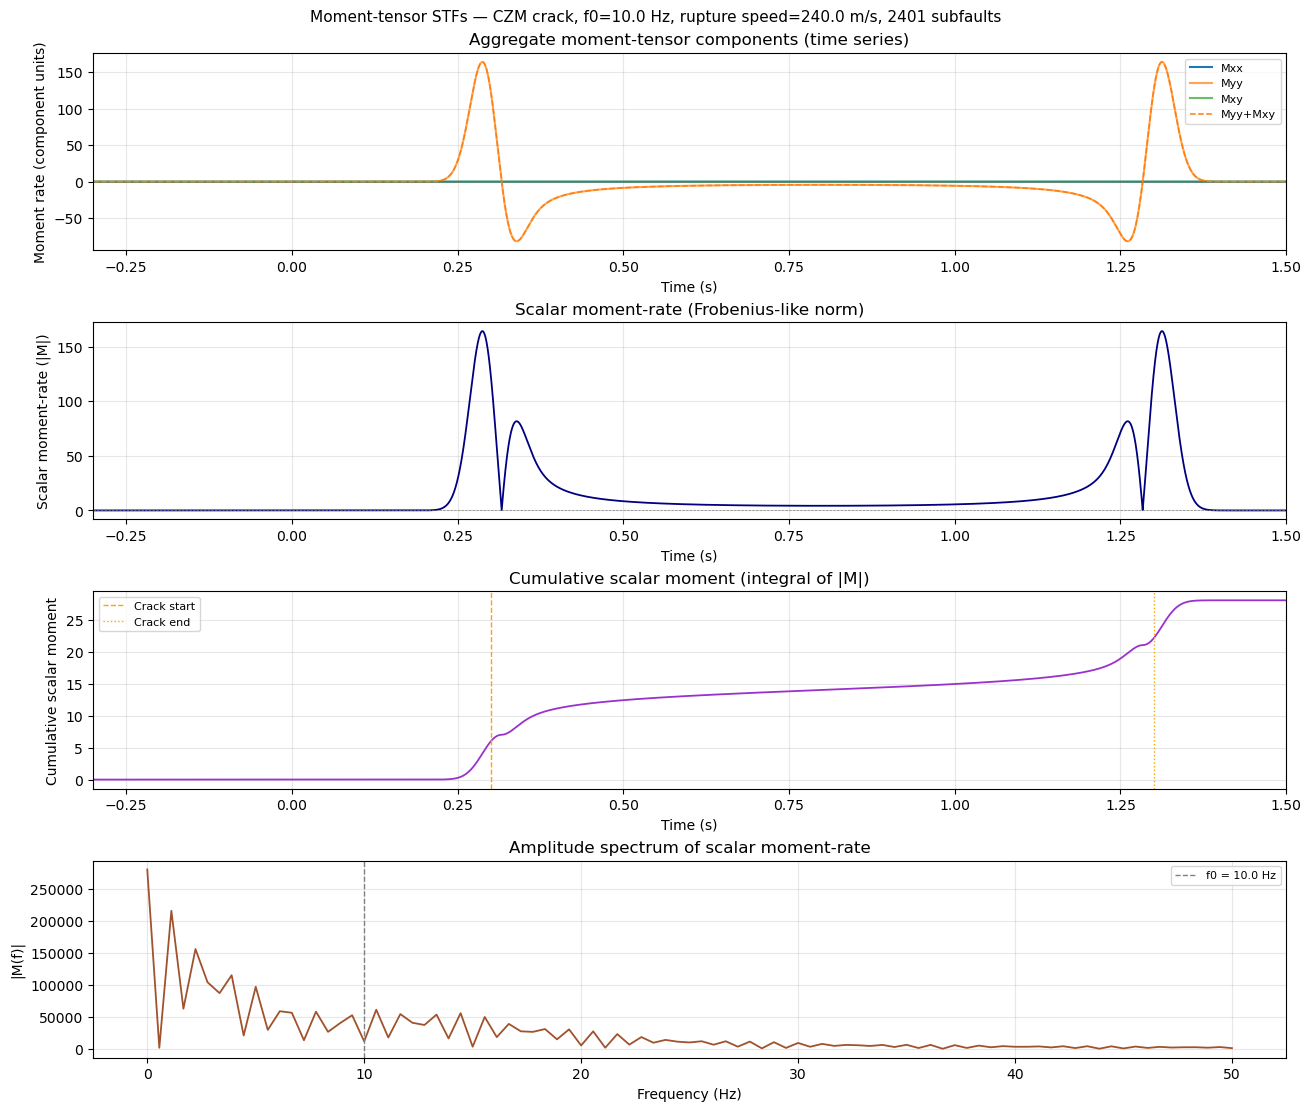

In [27]:
# Plot moment-tensor components of the source and derived diagnostics
import numpy as np
import matplotlib.pyplot as plt

# Time axis (match what was used when building sources)
pre_delay = 0.3
t_start = -pre_delay
t_end = subfaults[-1]["onset_time"] + subfaults[-1]["rise_time"] + 0.5
dt = 1e-4
t = np.arange(t_start, t_end, dt)
f0 = 10.0

# Ricker wavelet (same as used for STF construction)
def ricker(t, f0, t_shift):
    tau = t - t_shift
    u = (np.pi * f0 * tau) ** 2
    return (1.0 - 2.0 * u) * np.exp(-u)

# Accumulate component STFs
stf_mxx = np.zeros_like(t)
stf_myy = np.zeros_like(t)
stf_mxy = np.zeros_like(t)

# also keep a few example single-subfault STFs if useful
idx_early = 0
idx_mid = len(subfaults) // 2
idx_late = len(subfaults) - 1
stf_early = np.zeros_like(t)
stf_mid = np.zeros_like(t)
stf_late = np.zeros_like(t)

for i, sf in enumerate(subfaults):
    t_shift = pre_delay + sf["onset_time"] + sf["rise_time"] / 2.0
    w = ricker(t, f0, t_shift)
    mxx = sf.get("mxx", 0.0)
    myy = sf.get("myy", 0.0)
    mxy = sf.get("mxy", 0.0)

    stf_mxx += w * mxx
    stf_myy += w * myy
    stf_mxy += w * mxy

    if i == idx_early:
        stf_early = w * sf.get("mxy", 1.0)
    if i == idx_mid:
        stf_mid = w * sf.get("mxy", 1.0)
    if i == idx_late:
        stf_late = w * sf.get("mxy", 1.0)

# Combined Myy+Mxy
stf_myy_mxy = stf_myy + stf_mxy

# scalar moment-rate (Frobenius-like norm) for plotting/diagnostics
stf_scalar = np.sqrt(stf_mxx**2 + stf_myy**2 + 2.0 * stf_mxy**2)

# cumulative scalar moment
cumulative_moment = np.cumsum(stf_scalar) * dt

# Spectrum (use scalar moment-rate)
from numpy.fft import rfft, rfftfreq
freqs = rfftfreq(len(t), dt)
spec = np.abs(rfft(stf_scalar))
f_max = 5 * f0
f_mask = freqs <= f_max

# Plot: component STFs, scalar moment-rate, cumulative moment, spectrum
fig, axes = plt.subplots(4, 1, figsize=(13, 11), constrained_layout=True)

# Components: plot Mxx, Myy, Mxy and combined Myy+Mxy (dashed)
axes[0].plot(t, stf_mxx, label='Mxx', color='C0')
axes[0].plot(t, stf_myy, label='Myy', color='C1', alpha=0.7)
axes[0].plot(t, stf_mxy, label='Mxy', color='C2', alpha=0.7)
axes[0].plot(t, stf_myy_mxy, label='Myy+Mxy', color='C1', linestyle='--', lw=1.1)
axes[0].set_ylabel('Moment rate (component units)')
axes[0].set_title('Aggregate moment-tensor components (time series)')
axes[0].legend(fontsize=8)
axes[0].axhline(0, color='gray', lw=0.5, linestyle='--')
axes[0].grid(alpha=0.3)

# Scalar moment-rate
axes[1].plot(t, stf_scalar, color='navy', lw=1.3)
axes[1].set_ylabel('Scalar moment-rate (|M|)')
axes[1].set_title('Scalar moment-rate (Frobenius-like norm)')
axes[1].axhline(0, color='gray', lw=0.5, linestyle='--')
axes[1].grid(alpha=0.3)

# Cumulative
axes[2].plot(t, cumulative_moment, color='darkorchid', lw=1.3)
axes[2].set_ylabel('Cumulative scalar moment')
axes[2].set_title('Cumulative scalar moment (integral of |M|)')
axes[2].axvline(pre_delay, color='orange', lw=1.0, linestyle='--', label='Crack start')
axes[2].axvline(pre_delay + subfaults[-1]['onset_time'], color='orange', lw=1.0, linestyle=':', label='Crack end')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

# Spectrum of scalar moment-rate
axes[3].plot(freqs[f_mask], spec[f_mask], color='sienna', lw=1.3)
axes[3].axvline(f0, color='gray', lw=1.0, linestyle='--', label=f'f0 = {f0} Hz')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_ylabel('|M(f)|')
axes[3].set_title('Amplitude spectrum of scalar moment-rate')
axes[3].legend(fontsize=8)
axes[3].grid(alpha=0.3)

for ax in axes[:3]:
    ax.set_xlabel('Time (s)')
    ax.set_xlim(t_start, min(t_end, pre_delay + 3.0))

plt.suptitle(f'Moment-tensor STFs — CZM crack, f0={f0} Hz, rupture speed={rupture_speed} m/s, {len(subfaults)} subfaults', fontsize=11)
display(fig)
plt.close(fig)


rupture speed taken is 240.0


/tmp/ipykernel_2429197/184853925.py:61: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  ax.pcolormesh(


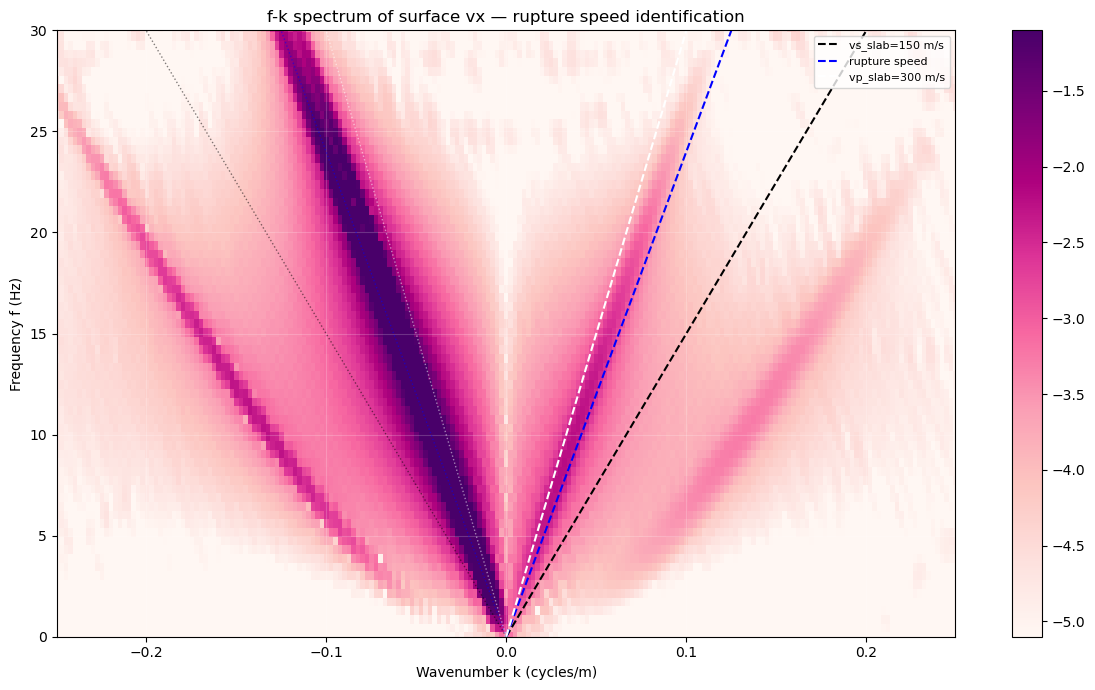

Interpretation:
Energy aligned with 'rupture speed' line -> correct rupture kinematics
Energy at vs_slab line -> S-wave cone (supershear: ahead of rupture front)
Energy at vrayleigh_slab line -> Rayleigh wave train behind crack tip


In [28]:
# Frequency domain analysis  f-k analysis- identify rupture speed and Mach cone
# print rupture speed to verify
print(f"rupture speed taken is {rupture_speed}")
# surface shot gather: gather (same as waterfall)
# Using vx (horizontal) at the slab surface — most sensitive to crack
y_recv  = 1.5   # snow surface in your coordinates
x_array = np.linspace(0, 400, 401)

sg = vel_2d_layered.sel(
    {y_name: y_recv},
    method="nearest"
).isel({c_name: 0}) # vx component

t_vals  = sg[t_name].values
x_vals  = sg[x_name].values
data    = sg.values # shape (nt, nx) or (nx, nt

# Ensure shape is (nt, nx)
if data.shape[0] == len(x_vals):
    data = data.T

dt = float(np.diff(t_vals).mean())
dx = float(np.diff(x_vals).mean())
nt, nx = data.shape

# 2D FFT - f-k spectrum
# Taper in both dimensions to reduce spectral leakage
taper_t = np.hanning(nt)
taper_x = np.hanning(nx)
data_tapered = data * taper_t[:, None] * taper_x[None, :]

fk = np.fft.fftshift(np.fft.fft2(data_tapered))
freqs = np.fft.fftshift(np.fft.fftfreq(nt, dt))
wns   = np.fft.fftshift(np.fft.fftfreq(nx, dx)) # wavenumber (cycles/m)

# Only plot positive frequencies
f_pos  = freqs >= 0
fk_pos = fk[f_pos, :]
f_plot = freqs[f_pos]

# Theoretical velocity lines to overlay
def velocity_line(v, freqs, wns):
    """k = f/v line in f-k space."""
    return freqs / v # k values for each frequency

velocities = {
    "vs_slab=150 m/s": 150.0,
    #"vrayleigh_slab=140 m/s": 140.0, # Rayleigh speed ≈ 0.92*vs
    "rupture speed": rupture_speed,
    "vp_slab=300 m/s": 300.0,
}
colors = ["black", "blue", "white", "green"]

fig, ax = plt.subplots(figsize=(12, 7))

# f-k power (log scale)
pk = np.log10(np.abs(fk_pos) + 1e-10)
vmax_pk = np.percentile(pk, 99)
vmin_pk = vmax_pk - 4 # 4 decades of dynamic range

ax.pcolormesh(
    wns, f_plot, pk,
    shading="none", cmap="RdPu",
    vmin=vmin_pk, vmax=vmax_pk,
)

# Overlay velocity lines: f = v*k → k = f/v
k_max = wns.max()
for (label, v), col in zip(velocities.items(), colors):
    k_line = f_plot / v
    mask = np.abs(k_line) <= k_max
    ax.plot(k_line[mask], f_plot[mask], color=col, lw=1.5,
            linestyle="--", label=label)
    # Also negative k (retrograde branch)
    ax.plot(-k_line[mask], f_plot[mask], color=col, lw=1.0,
            linestyle=":", alpha=0.5)

ax.set_xlim(-k_max * 0.5, k_max * 0.5)
ax.set_ylim(0, min(3 * f0, freqs.max()))
ax.set_xlabel("Wavenumber k (cycles/m)")
ax.set_ylabel("Frequency f (Hz)")
ax.set_title("f-k spectrum of surface vx — rupture speed identification")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.2, color="white")

# Plot colorbar for energy 
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap="RdPu", norm=plt.Normalize(vmin=vmin_pk, vmax=vmax_pk)),
    ax=ax
)

plt.tight_layout()
display(fig)
plt.close(fig)

print("Interpretation:")
print("Energy aligned with 'rupture speed' line -> correct rupture kinematics")
print("Energy at vs_slab line -> S-wave cone (supershear: ahead of rupture front)")
print("Energy at vrayleigh_slab line -> Rayleigh wave train behind crack tip")

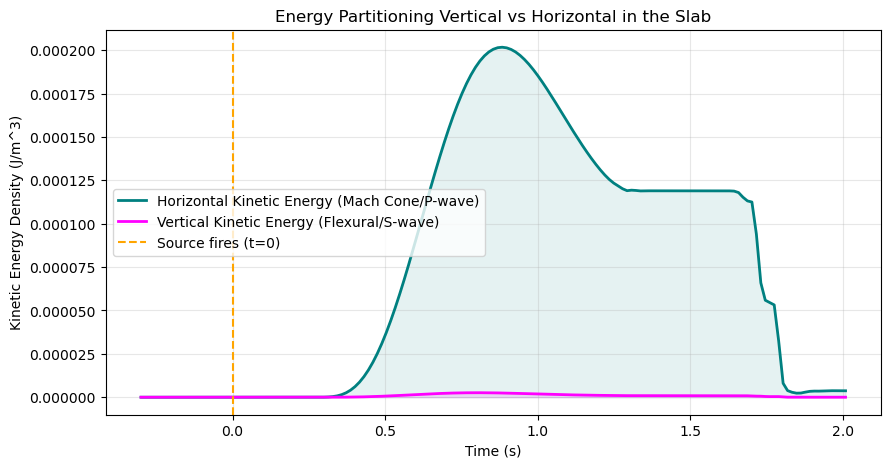

Energy Ratio (KE_x / KE_y): 95.63


In [29]:
# Energy partition calculations
# Look at how enegry is distributed in the horizontal and the vertical in the slab

# Extracting only velocities in the slab (from y=0 to y=1.5 m)
slab_vel = vel_2d_layered.sel({y_name: slice(0, 1.5)})
slab_vx = slab_vel.isel({c_name: 0}) # vx component
slab_vy = slab_vel.isel({c_name: 1}) # vy component

# calculating average velocity for each time step to get eneryg density 
mean_vx_sq = (slab_vx**2).mean(dim=[x_name, y_name])
mean_vy_sq = (slab_vy**2).mean(dim=[x_name, y_name])

# Density 
rho_slab = 180
ke_x = 0.5 * rho_slab * mean_vx_sq
ke_y = 0.5 * rho_slab * mean_vy_sq
total_ke = ke_x + ke_y 

# Plotting the kinetic energy partition 
fig, ax = plt.subplots(figsize=(10, 5))
t_axis = slab_vel[t_name].values

ax.plot(t_axis, ke_x, label="Horizontal Kinetic Energy (Mach Cone/P-wave)", color='teal', lw=2)
ax.plot(t_axis, ke_y, label="Vertical Kinetic Energy (Flexural/S-wave)", color='magenta', lw=2)
ax.fill_between(t_axis, 0, ke_x, color='teal', alpha=0.1)
ax.fill_between(t_axis, 0, ke_y, color='magenta', alpha=0.1)

# Plotting line for source firing time
ax.axvline(0, color='orange', lw=1.5, linestyle='--', label='Source fires (t=0)')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Kinetic Energy Density (J/m^3)")
ax.set_title("Energy Partitioning Vertical vs Horizontal in the Slab")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

# Calculate the Ratio
ratio = (ke_x.sum() / ke_y.sum()).values
print(f"Energy Ratio (KE_x / KE_y): {ratio:.2f}")

Precursor arrival time at x=200.0 m: 0.884 s
Main arrival time at x=200.0 m: 0.943 s


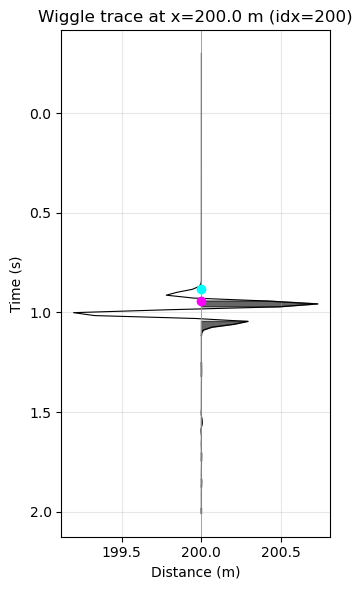

Time difference between main arrival and precursor: 0.058 s
Estimated velocity of precursor wave: 226.2 m/s
Estimated velocity of main wave: 212.2 m/s


In [30]:
# Picking precursor time 

target_x = 200.0



# get x coordinates (tries common names used in this notebook)
if 'x_line' in globals():
    x_coords = np.asarray(x_line)
elif 'sg' in globals() and 'x' in sg.coords:
    x_coords = np.asarray(sg['x'].values)
else:
    raise RuntimeError("Couldn't find `x_line` or `sg['x']` in the notebook namespace.")

# find nearest receiver index to 200 m
idx = int(np.argmin(np.abs(x_coords - target_x)))
# extract trace (robust for xarray DataArray)
try:
    trace_da = sg_vx.isel({x_name: idx})
except Exception:
    trace_da = sg_vx.sel(x=x_coords[idx], method='nearest')

trace = np.asarray(trace_da.values).squeeze()

# time vector
if t_name in trace_da.coords:
    t = np.asarray(trace_da[t_name].values)
elif 't' in trace_da.coords:
    t = np.asarray(trace_da['t'].values)
else:
    raise RuntimeError("Couldn't find time coordinate (`t` or t_name) for the trace.")

# normalize and build wiggle at receiver location
tr = trace / (np.nanmax(np.abs(trace)) + 1e-16)
dx = np.mean(np.diff(x_coords)) if x_coords.size > 1 else 1.0
scale = 0.8 * dx
x0 = x_coords[idx]
xwig = tr * scale + x0

# picking time of first precursor arrival (fluexural wave )
threshold = 0.05 * np.max(np.abs(tr))
precursor_indices = np.where(np.abs(tr) > threshold)[0]
if len(precursor_indices) > 0:
    precursor_time = t[precursor_indices[0]]
    print(f"Precursor arrival time at x={x0:.1f} m: {precursor_time:.3f} s")
else:
    print(f"No precursor detected at x={x0:.1f} m with threshold {threshold:.3e}")

# picking arrival of second, larger wave (main arrival )
main_threshold = 0.5 * np.max(np.abs(tr))
main_indices = np.where(np.abs(tr) > main_threshold)[0]
if len(main_indices) > 0:
    main_time = t[main_indices[0]]
    print(f"Main arrival time at x={x0:.1f} m: {main_time:.3f} s")
else:
    print(f"No main arrival detected at x={x0:.1f} m with threshold {main_threshold:.3e}")



# plot (time vertical)
fig, ax = plt.subplots(figsize=(3.5, 6))
ax.plot(xwig, t, color='k', lw=0.8)
ax.fill_betweenx(t, x0, xwig, where=(xwig > x0), color='k', alpha=0.6)
ax.axvline(x0, color='0.6', lw=0.6)  # zero line
# plotting dots for arrivals picked 
if len(precursor_indices) > 0:
    ax.plot(x0, precursor_time, 'o', color='cyan', label='Precursor arrival')
if len(main_indices) > 0:
    ax.plot(x0, main_time, 'o', color='magenta', label='Main arrival')
ax.invert_yaxis()
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Time (s)')
ax.set_title(f'Wiggle trace at x={x0:.1f} m (idx={idx})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# calculating difference between arrival times
if len(precursor_indices) > 0 and len(main_indices) > 0:
    time_diff = main_time - precursor_time
    print(f"Time difference between main arrival and precursor: {time_diff:.3f} s")
else:    print("Could not calculate time difference due to missing arrivals.")

# calculate distance from source to reciever
source_x = 0.0
source_y = 0.0
receiver_x = x0
receiver_y = y_recv
distance = np.sqrt((receiver_x - source_x)**2 + (receiver_y - source_y)**2)
# velocity from this
if len(precursor_indices) > 0:
    velocity_precursor = distance / precursor_time
    print(f"Estimated velocity of precursor wave: {velocity_precursor:.1f} m/s")
if len(main_indices) > 0:
    velocity_main = distance / main_time
    print(f"Estimated velocity of main wave: {velocity_main:.1f} m/s")


In [31]:
# Checks for wave speed
# From Graff, 1975 and Achenbach, 1975: cp = 2vs sqrt(1-(vs^2/vp^2))

# SImulation vs and vp values in snow
vs = 150
vp = 300

# Calculate the wave speeed according to derived equation
cp = 2 * vs * np.sqrt(1 - (vs**2 / vp**2))
print(f"Analytical S0 Wave Speed: {cp:.2f} m/s")

# Compare to simulation rupture speed
vr_sim = 1.6 * vs 
print(f"Simulated Rupture Speed: {vr_sim:.2f} m/s")

diff = abs(cp - vr_sim)
print(f"Difference: {diff:.2f} m/s")

Analytical S0 Wave Speed: 259.81 m/s
Simulated Rupture Speed: 240.00 m/s
Difference: 19.81 m/s
